# XGBoost Temperature Prediction: 5 vs 10 Minutes

This notebook mirrors the 07 LGBM temperature prediction structure, but uses XGBoost. The 5-minute and 10-minute horizons are trained separately so the comparison is not mixed with a global multi-horizon model design.


## Setup


In [1]:
from pathlib import Path
from types import SimpleNamespace
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from xgboost_forecast import build_multihorizon_dataset, run_multihorizon_forecast_pipeline

config.ensure_output_dirs()


## Configuration


In [2]:
TEMPERATURE_COLUMN = 'temp_mean_c'
TARGET_MINUTES_LIST = [5.0, 10.0]
PEOPLE_OR_MACHINE = 'machine'

TRAIN_DATES = ['2025-04-23', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-06', '2025-05-07']
VALID_DATES = ['2025-04-25']
TEST_DATES = ['2025-04-24', '2025-05-02']

VALID_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42
GROUP_MODELS = False
GROUP_MODEL_COLUMN = 'canonical_label'

# Set True after running 08_1 and confirming tuned XGBoost parameters are useful.
USE_TUNED_XGBOOST_PARAMS = True
TUNED_XGBOOST_PARAMS_JSON = config.XGBOOST_OUTPUT_DIR / 'tuning' / 'best_xgboost_params.json'

XGBOOST_HORIZON_COMPARE_DIR = config.XGBOOST_OUTPUT_DIR / 'horizon_compare'
XGBOOST_HORIZON_COMPARE_DIR.mkdir(parents=True, exist_ok=True)


def horizon_tag(target_minutes):
    return f'{int(target_minutes):02d}min' if float(target_minutes).is_integer() else f'{target_minutes:g}min'.replace('.', 'p')


def load_tuned_xgboost_params(path):
    if not path.exists():
        raise FileNotFoundError(f'Tuned XGBoost params JSON not found. Run notebook 08_1 first: {path}')
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


tuned_xgboost_params_by_horizon = load_tuned_xgboost_params(TUNED_XGBOOST_PARAMS_JSON) if USE_TUNED_XGBOOST_PARAMS else {}


def get_xgboost_model_params(target_minutes):
    if not USE_TUNED_XGBOOST_PARAMS:
        return None
    tag = horizon_tag(target_minutes)
    if tag not in tuned_xgboost_params_by_horizon:
        raise KeyError(f'Missing tuned XGBoost params for {tag} in {TUNED_XGBOOST_PARAMS_JSON}')
    return tuned_xgboost_params_by_horizon[tag]


def make_xgboost_args(target_minutes):
    base_dir = XGBOOST_HORIZON_COMPARE_DIR
    if USE_TUNED_XGBOOST_PARAMS:
        base_dir = base_dir / 'tuned'
    output_dir = base_dir / horizon_tag(target_minutes)
    output_dir.mkdir(parents=True, exist_ok=True)
    return SimpleNamespace(
        input_csv=config.OBJECT_TIMELINE_CSV,
        output_dir=output_dir,
        prediction_csv=output_dir / 'xgboost_temperature_predictions.csv',
        metrics_csv=output_dir / 'xgboost_metrics.csv',
        feature_importance_csv=output_dir / 'xgboost_feature_importance.csv',
        learning_curve_png=output_dir / 'xgboost_learning_curve.png',
        temperature_column=TEMPERATURE_COLUMN,
        forecast_horizons_min=[target_minutes],
        people_or_machine=PEOPLE_OR_MACHINE,
        train_dates=TRAIN_DATES,
        valid_dates=VALID_DATES,
        test_dates=TEST_DATES,
        valid_ratio=VALID_RATIO,
        test_ratio=TEST_RATIO,
        group_models=GROUP_MODELS,
        group_model_column=GROUP_MODEL_COLUMN,
        random_state=RANDOM_STATE,
        model_params=get_xgboost_model_params(target_minutes),
    )


xgboost_args_by_horizon = {target_minutes: make_xgboost_args(target_minutes) for target_minutes in TARGET_MINUTES_LIST}

{
    'use_tuned_xgboost_params': USE_TUNED_XGBOOST_PARAMS,
    'tuned_xgboost_params_json': str(TUNED_XGBOOST_PARAMS_JSON),
    'output_dirs': {horizon_tag(target_minutes): str(args.prediction_csv.parent) for target_minutes, args in xgboost_args_by_horizon.items()},
    'model_params': {horizon_tag(target_minutes): args.model_params for target_minutes, args in xgboost_args_by_horizon.items()},
}


{'use_tuned_xgboost_params': True,
 'tuned_xgboost_params_json': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/tuning/best_xgboost_params.json',
 'output_dirs': {'05min': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min',
  '10min': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/10min'},
 'model_params': {'05min': {'n_estimators': 2000,
   'reg_alpha': 0.0,
   'reg_lambda': 1.0,
   'tree_method': 'hist',
   'enable_categorical': True,
   'early_stopping_rounds': 80,
   'max_depth': 3,
   'learning_rate': 0.07308623105480647,
   'min_child_weight': 4.812697463759088,
   'subsample': 0.6329901547633111,
   'colsample_bytree': 0.6260423521410341},
  '10min': {'n_estimators': 2000,
   'reg_alpha': 0.0,
   'reg_lambda': 1.0,
   'tree_method': 'hist',
   'enable_categorical': True,
   'early_stopping_rounds': 80,
   'max_depth': 3,
   'learning_rate': 

## Build Feature Preview


In [3]:
model_preview_by_horizon = {}
feature_columns_by_horizon = {}
summary_rows = []

for target_minutes, args in xgboost_args_by_horizon.items():
    preview_df, preview_features = build_multihorizon_dataset(
        timeline_csv=args.input_csv,
        temperature_column=args.temperature_column,
        forecast_horizons_min=args.forecast_horizons_min,
        people_or_machine=args.people_or_machine,
    )
    model_preview_by_horizon[target_minutes] = preview_df
    feature_columns_by_horizon[target_minutes] = preview_features
    summary_rows.append({
        'target_minutes': target_minutes,
        'rows': len(preview_df),
        'objects': preview_df['object_id'].nunique(),
        'source_start': preview_df['timestamp_dt'].min(),
        'source_end': preview_df['timestamp_dt'].max(),
        'target_start': preview_df['target_timestamp'].min(),
        'target_end': preview_df['target_timestamp'].max(),
        'actual_target_min': preview_df['target_minutes_ahead'].min(),
        'actual_target_median': preview_df['target_minutes_ahead'].median(),
        'actual_target_max': preview_df['target_minutes_ahead'].max(),
        'feature_count': len(preview_features),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

feature_columns_comparison = pd.DataFrame({
    f'{horizon_tag(target_minutes)}_features': pd.Series(feature_columns_by_horizon[target_minutes])
    for target_minutes in TARGET_MINUTES_LIST
})
display(feature_columns_comparison)


,target_minutes,rows,objects,source_start,source_end,target_start,target_end,actual_target_min,actual_target_median,actual_target_max,feature_count
0,5.0,55249,14,2025-04-23 13:43:32,2025-05-07 15:12:46,2025-04-23 13:48:32,2025-05-07 15:17:46,5.0,5.0,7.5,61
1,10.0,55027,14,2025-04-23 13:43:32,2025-05-07 15:07:46,2025-04-23 13:53:32,2025-05-07 15:17:46,10.0,10.0,15.0,61


,05min_features,10min_features
0,object_id,object_id
1,canonical_label,canonical_label
2,display_x,display_x
3,display_y,display_y
4,anchor_x,anchor_x
...,...,...
56,temp_delta_1,temp_delta_1
57,seconds_since_previous,seconds_since_previous
58,observations_in_frame,observations_in_frame
59,target_minutes_ahead,target_minutes_ahead


In [4]:
preview_df = model_preview_by_horizon[TARGET_MINUTES_LIST[0]]
preview_df[[
    'object_id',
    'canonical_label',
    'timestamp',
    'target_timestamp',
    'requested_horizon_min',
    'target_minutes_ahead',
    TEMPERATURE_COLUMN,
    'target_temp',
]].head(20)


,object_id,canonical_label,timestamp,target_timestamp,requested_horizon_min,target_minutes_ahead,temp_mean_c,target_temp
0,cableduct_1,Cableduct,2025-04-23 13:44:33,2025-04-23 13:50:02,5.0,5.483333,21.039400,21.212208
1,cableduct_1,Cableduct,2025-04-23 13:45:02,2025-04-23 13:50:02,5.0,5.000000,21.079897,21.212208
2,cableduct_1,Cableduct,2025-04-23 13:45:32,2025-04-23 13:50:33,5.0,5.016667,21.046547,21.297585
3,cableduct_1,Cableduct,2025-04-23 13:46:02,2025-04-23 13:51:02,5.0,5.000000,21.069269,21.293106
4,cableduct_1,Cableduct,2025-04-23 13:46:32,2025-04-23 13:51:32,5.0,5.000000,21.063841,21.204048
5,cableduct_1,Cableduct,2025-04-23 13:47:02,2025-04-23 13:52:02,5.0,5.000000,21.061125,21.134014
6,cableduct_1,Cableduct,2025-04-23 13:47:32,2025-04-23 13:52:32,5.0,5.000000,21.069017,21.148827
7,cableduct_1,Cableduct,2025-04-23 13:48:02,2025-04-23 13:53:02,5.0,5.000000,21.044666,21.107422
8,cableduct_1,Cableduct,2025-04-23 13:48:32,2025-04-23 13:53:32,5.0,5.000000,21.055481,21.089634
9,cableduct_1,Cableduct,2025-04-23 13:49:02,2025-04-23 13:54:03,5.0,5.016667,21.194807,21.058735


## Train XGBoost and Compare 5 vs 10 Minutes


Training XGBoost horizon: 5 minutes
Training XGBoost horizon: 10 minutes


,target_minutes,split,requested_horizon_min,rows,mae,rmse,r2,mean_error,ci_width_mean,ci_coverage
0,5.0,test,5.0,15350,0.297094,0.420094,0.753201,0.024699,1.552315,0.931010
1,5.0,train,5.0,32475,0.308152,0.470945,0.827103,-0.000047,1.668924,0.952179
2,5.0,valid,5.0,7424,0.416435,0.557637,0.486497,0.177834,1.525604,0.706762
3,10.0,test,10.0,15275,0.330800,0.451726,0.714265,0.041187,1.708624,0.924124
4,10.0,train,10.0,32375,0.338679,0.505710,0.801513,-0.000283,1.811731,0.951876
5,10.0,valid,10.0,7377,0.475138,0.610919,0.412082,0.213828,1.755469,0.666938


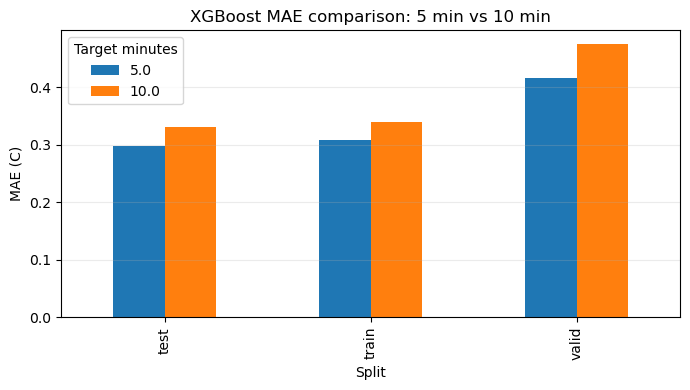

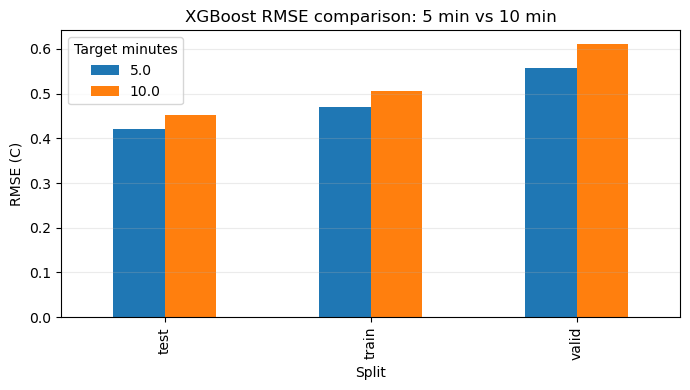

In [5]:
results_by_horizon = {}
metrics_tables = []

for target_minutes, args in xgboost_args_by_horizon.items():
    print(f'Training XGBoost horizon: {target_minutes:g} minutes')
    horizon_result = run_multihorizon_forecast_pipeline(args)
    results_by_horizon[target_minutes] = horizon_result

    metrics_part = horizon_result['metrics'].copy()
    metrics_part.insert(0, 'target_minutes', target_minutes)
    metrics_tables.append(metrics_part)

metrics_comparison = pd.concat(metrics_tables, ignore_index=True)
display(metrics_comparison)

for metric in ['mae', 'rmse']:
    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = metrics_comparison.pivot(index='split', columns='target_minutes', values=metric)
    plot_df.plot(kind='bar', ax=ax)
    ax.set_title(f'XGBoost {metric.upper()} comparison: 5 min vs 10 min')
    ax.set_xlabel('Split')
    ax.set_ylabel(f'{metric.upper()} (C)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title='Target minutes')
    fig.tight_layout()


## Learning Curves


{'05min': {'train': OrderedDict([('rmse',
                [1.069267385299054,
                 1.0114169580633952,
                 0.958787823637535,
                 0.9111508156993247,
                 0.8672787258653087,
                 0.8271911223387478,
                 0.791006951724926,
                 0.7585459082908763,
                 0.728725815436538,
                 0.7020422206914748,
                 0.677569457534355,
                 0.6560443952860734,
                 0.6367369587814977,
                 0.6195984810140727,
                 0.6040268215759103,
                 0.590299048264943,
                 0.5782008374841102,
                 0.5673318809125785,
                 0.5577319005364979,
                 0.5490184215861441,
                 0.5414194863791885,
                 0.5346985477449184,
                 0.528916846179334,
                 0.5239050389673475,
                 0.5193104800852563,
                 0.5153393887246335,
   

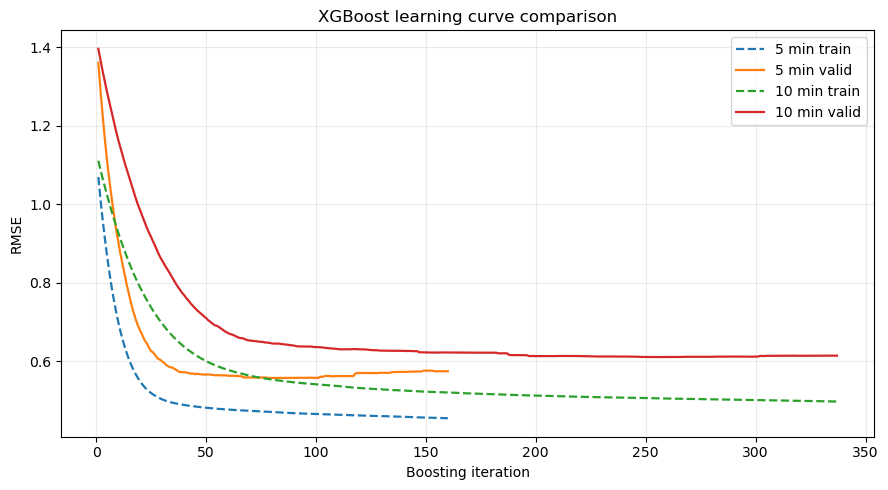

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for target_minutes, horizon_result in results_by_horizon.items():
    evals = horizon_result['evals_result']
    for split_name, linestyle in [('train', '--'), ('valid', '-')]:
        rmse_values = evals.get(split_name, {}).get('rmse', [])
        if rmse_values:
            ax.plot(
                range(1, len(rmse_values) + 1),
                rmse_values,
                linestyle=linestyle,
                linewidth=1.6,
                label=f'{target_minutes:g} min {split_name}',
            )
ax.set_title('XGBoost learning curve comparison')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('RMSE')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

{horizon_tag(target_minutes): horizon_result['evals_result'] for target_minutes, horizon_result in results_by_horizon.items()}


## Outputs


In [7]:
output_summary = {
    horizon_tag(target_minutes): {
        'prediction_csv': str(args.prediction_csv),
        'metrics_csv': str(args.metrics_csv),
        'feature_importance_csv': str(args.feature_importance_csv),
        'learning_curve_png': str(args.learning_curve_png),
        'model_dir': str(args.output_dir),
    }
    for target_minutes, args in xgboost_args_by_horizon.items()
}
output_summary


{'05min': {'prediction_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min/xgboost_temperature_predictions.csv',
  'metrics_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min/xgboost_metrics.csv',
  'feature_importance_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min/xgboost_feature_importance.csv',
  'learning_curve_png': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min/xgboost_learning_curve.png',
  'model_dir': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min'},
 '10min': {'prediction_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/10min/xgboost_temperature_predictions.csv',
  'metrics_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intersh

## Test-Only Prediction CSVs


In [8]:
test_prediction_paths = {}
for target_minutes, args in xgboost_args_by_horizon.items():
    predictions = pd.read_csv(args.prediction_csv)
    test_predictions = predictions[predictions['split'] == 'test'].copy()
    output_csv = args.prediction_csv.with_name('xgboost_temperature_predictions_test.csv')
    test_predictions.to_csv(output_csv, index=False)
    test_prediction_paths[horizon_tag(target_minutes)] = {
        'path': str(output_csv),
        'rows': len(test_predictions),
        'dates': sorted(pd.to_datetime(test_predictions['timestamp']).dt.date.astype(str).unique().tolist()),
    }

test_prediction_paths


{'05min': {'path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/05min/xgboost_temperature_predictions_test.csv',
  'rows': 15350,
  'dates': ['2025-04-24', '2025-05-02']},
 '10min': {'path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/horizon_compare/tuned/10min/xgboost_temperature_predictions_test.csv',
  'rows': 15275,
  'dates': ['2025-04-24', '2025-05-02']}}

## Feature Importance Comparison


target_minutes,5.0,10.0
feature,,
temp_roll_mean_20,0.314152,0.196052
temp_roll_mean_5,0.207235,0.168969
temp_roll_mean_30,0.113826,0.066762
temp_roll_mean_10,0.108413,0.302819
source_temp,0.075090,0.046090
temp_lag_2,0.050409,0.011410
temp_lag_3,0.018354,0.014755
temp_lag_1,0.013406,0.019121
temp_lag_14,0.005204,0.003234


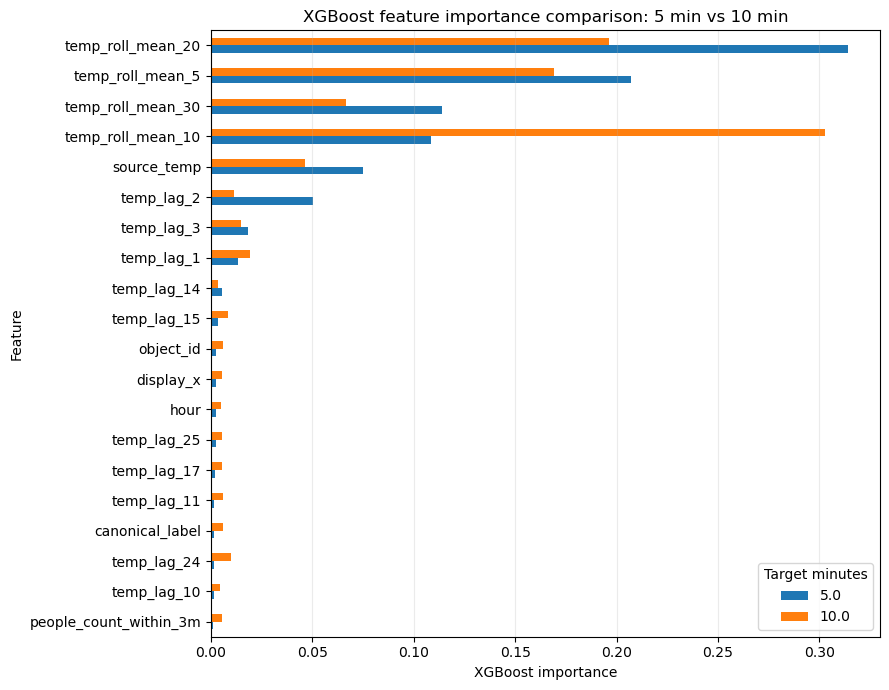

In [9]:
importance_tables = []
for target_minutes, horizon_result in results_by_horizon.items():
    part = horizon_result['feature_importance'].copy()
    part['target_minutes'] = target_minutes
    importance_tables.append(part)

importance_all = pd.concat(importance_tables, ignore_index=True)
importance_pivot = (
    importance_all.pivot_table(index='feature', columns='target_minutes', values='importance', fill_value=0)
    .sort_values(TARGET_MINUTES_LIST[0], ascending=False)
)
display(importance_pivot.head(30))

top_features = importance_pivot.max(axis=1).sort_values(ascending=False).head(20).index
plot_df = importance_pivot.loc[top_features].sort_values(TARGET_MINUTES_LIST[0])
fig, ax = plt.subplots(figsize=(9, 7))
plot_df.plot(kind='barh', ax=ax)
ax.set_title('XGBoost feature importance comparison: 5 min vs 10 min')
ax.set_xlabel('XGBoost importance')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()


## Error and CI Summary


,target_minutes,split,requested_horizon_min,rows,mae,rmse,r2,mean_error,ci_width_mean,ci_coverage
0,5.0,test,5.0,15350,0.297094,0.420094,0.753201,0.024699,1.552315,0.931010
3,10.0,test,10.0,15275,0.330800,0.451726,0.714265,0.041187,1.708624,0.924124


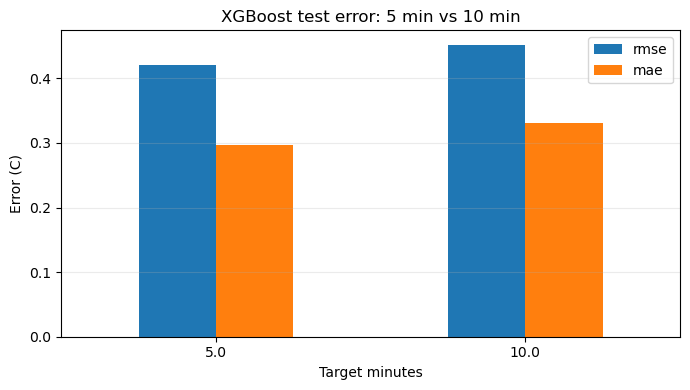

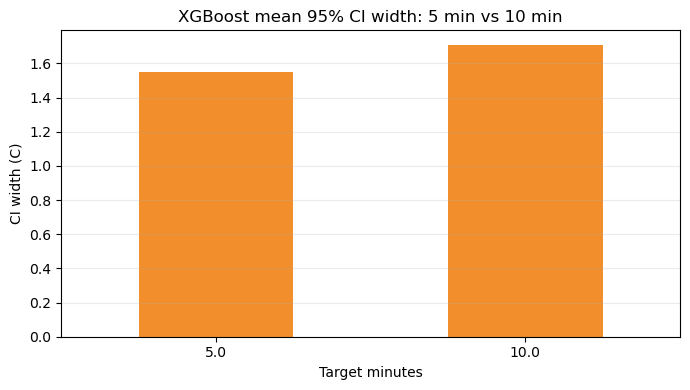

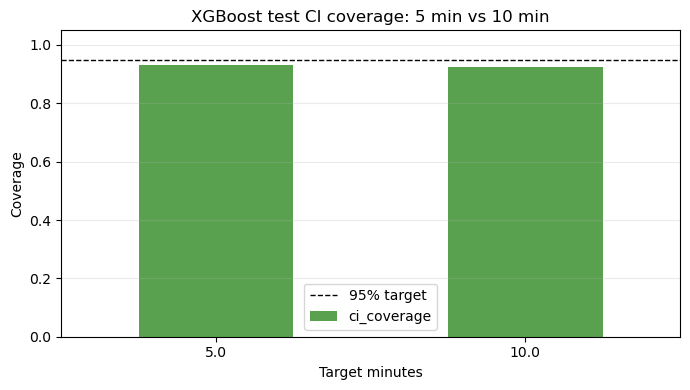

In [10]:
test_metrics = metrics_comparison.query("split == 'test'").copy()
display(test_metrics)

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = test_metrics.set_index('target_minutes')[['rmse', 'mae']]
plot_df.plot(kind='bar', ax=ax)
ax.set_title('XGBoost test error: 5 min vs 10 min')
ax.set_xlabel('Target minutes')
ax.set_ylabel('Error (C)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = test_metrics.set_index('target_minutes')[['ci_width_mean']]
plot_df.plot(kind='bar', ax=ax, color='#f28e2b', legend=False)
ax.set_title('XGBoost mean 95% CI width: 5 min vs 10 min')
ax.set_xlabel('Target minutes')
ax.set_ylabel('CI width (C)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = test_metrics.set_index('target_minutes')[['ci_coverage']]
plot_df.plot(kind='bar', ax=ax, color='#59a14f', legend=False)
ax.axhline(0.95, color='black', linestyle='--', linewidth=1, label='95% target')
ax.set_title('XGBoost test CI coverage: 5 min vs 10 min')
ax.set_xlabel('Target minutes')
ax.set_ylabel('Coverage')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()


## Prediction vs Ground Truth with 95% CI


In [11]:
test_pred_parts = []
ci_rows = []

for target_minutes, horizon_result in results_by_horizon.items():
    part_pred = horizon_result['predictions'].query("split == 'test'").copy()
    part_pred['target_minutes'] = target_minutes
    part_pred['ci_width'] = part_pred['ci_upper'] - part_pred['ci_lower']
    test_pred_parts.append(part_pred)

    for (object_id, canonical_label), object_part in part_pred.groupby(['object_id', 'canonical_label'], sort=True):
        error = object_part['error'].dropna()
        if error.empty:
            continue
        ci_rows.append({
            'target_minutes': target_minutes,
            'object_id': object_id,
            'canonical_label': canonical_label,
            'rows': len(object_part),
            'ci_width': object_part['ci_width'].mean(),
            'coverage': object_part['covered_by_95ci'].mean(),
            'rmse': np.sqrt((error ** 2).mean()),
            'mae': error.abs().mean(),
            'mean_error': error.mean(),
        })

test_pred = pd.concat(test_pred_parts, ignore_index=True)
ci_metrics = pd.DataFrame(ci_rows).sort_values(['target_minutes', 'ci_width'])
ci_metrics


,target_minutes,object_id,canonical_label,rows,ci_width,coverage,rmse,mae,mean_error
7,5.0,machine_3,Machine,253,1.038657,0.849802,0.232510,0.196796,0.168586
8,5.0,machine_4,Machine,789,1.161178,0.929024,0.311750,0.218107,0.003843
11,5.0,screen_2,Screen,1856,1.342037,0.919720,0.394242,0.264484,0.033324
6,5.0,machine_2,Machine,1426,1.360187,0.920757,0.405698,0.269626,0.026718
0,5.0,cableduct_1,Cableduct,1236,1.507623,0.899676,0.473941,0.339823,0.015061
2,5.0,cableduct_3,Cableduct,1762,1.517595,0.939274,0.392585,0.283102,0.008971
5,5.0,machine_1,Machine,414,1.523059,0.951691,0.300073,0.227263,0.114367
9,5.0,machine_6,Machine,1605,1.531207,0.941433,0.384023,0.281534,0.019719
12,5.0,window_1,Window,644,1.593605,0.934783,0.389561,0.292829,-0.022321
1,5.0,cableduct_2,Cableduct,1582,1.633144,0.943110,0.456430,0.327725,0.009901


## Confidence by Object and Horizon


target_minutes,5.0,10.0
object_id,,
machine_3,1.038657,1.172286
machine_4,1.161178,1.340501
screen_2,1.342037,1.420451
machine_2,1.360187,1.619036
machine_6,1.531207,1.555372
cableduct_3,1.517595,1.618328
cableduct_1,1.507623,1.648780
machine_1,1.523059,1.754197
window_1,1.593605,1.704206


Most confident objects have the narrowest CI width.


,target_minutes,object_id,canonical_label,rows,ci_width,coverage,rmse,mae,mean_error
7,5.0,machine_3,Machine,253,1.038657,0.849802,0.232510,0.196796,0.168586
8,5.0,machine_4,Machine,789,1.161178,0.929024,0.311750,0.218107,0.003843
11,5.0,screen_2,Screen,1856,1.342037,0.919720,0.394242,0.264484,0.033324
6,5.0,machine_2,Machine,1426,1.360187,0.920757,0.405698,0.269626,0.026718
0,5.0,cableduct_1,Cableduct,1236,1.507623,0.899676,0.473941,0.339823,0.015061
2,5.0,cableduct_3,Cableduct,1762,1.517595,0.939274,0.392585,0.283102,0.008971
5,5.0,machine_1,Machine,414,1.523059,0.951691,0.300073,0.227263,0.114367
9,5.0,machine_6,Machine,1605,1.531207,0.941433,0.384023,0.281534,0.019719
12,5.0,window_1,Window,644,1.593605,0.934783,0.389561,0.292829,-0.022321
1,5.0,cableduct_2,Cableduct,1582,1.633144,0.943110,0.456430,0.327725,0.009901


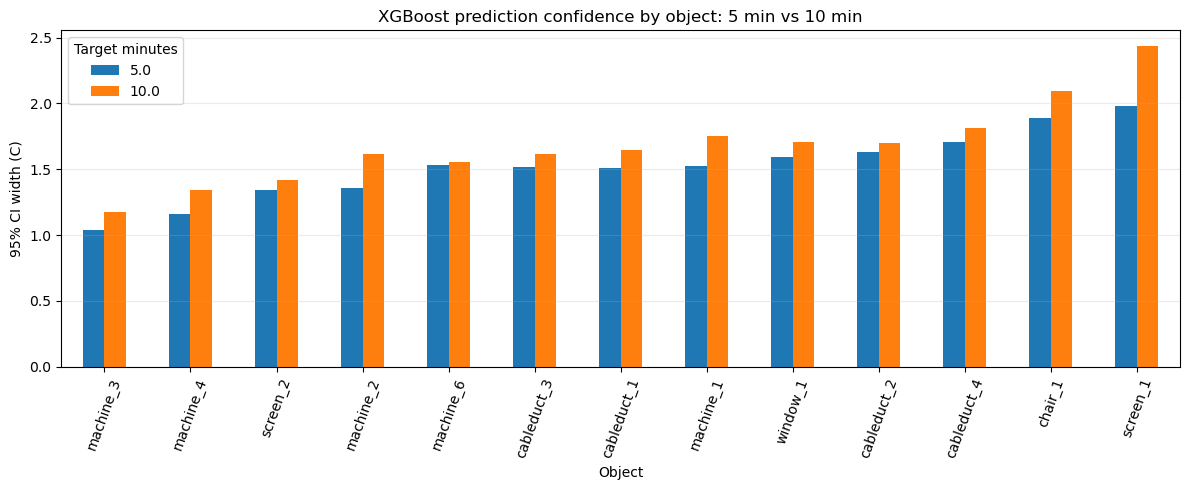

In [12]:
confidence_pivot = ci_metrics.pivot_table(index='object_id', columns='target_minutes', values='ci_width')
confidence_pivot = confidence_pivot.loc[confidence_pivot.mean(axis=1).sort_values().index]
display(confidence_pivot)

fig, ax = plt.subplots(figsize=(12, 5))
confidence_pivot.plot(kind='bar', ax=ax)
ax.set_title('XGBoost prediction confidence by object: 5 min vs 10 min')
ax.set_xlabel('Object')
ax.set_ylabel('95% CI width (C)')
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()

print('Most confident objects have the narrowest CI width.')
display(ci_metrics[['target_minutes', 'object_id', 'canonical_label', 'rows', 'ci_width', 'coverage', 'rmse', 'mae', 'mean_error']].head(20))


## CI Coverage by Object and Horizon


target_minutes,5.0,10.0
object_id,,
screen_1,0.943407,0.942382
cableduct_2,0.943110,0.941473
machine_1,0.951691,0.929907
machine_6,0.941433,0.938356
cableduct_4,0.937739,0.931718
cableduct_3,0.939274,0.927594
window_1,0.934783,0.927469
machine_4,0.929024,0.927083
machine_2,0.920757,0.931818


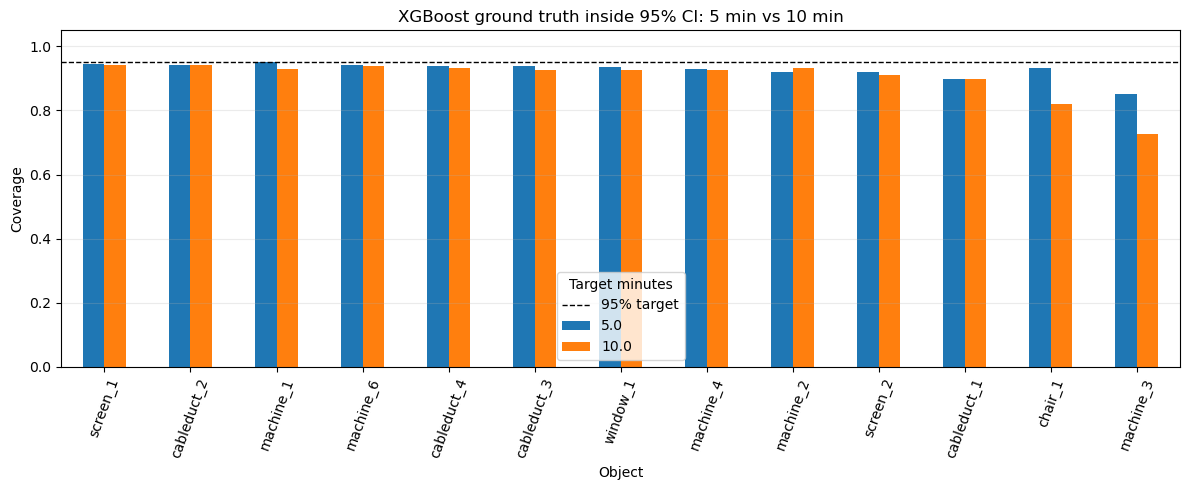

In [13]:
coverage_pivot = ci_metrics.pivot_table(index='object_id', columns='target_minutes', values='coverage')
coverage_pivot = coverage_pivot.loc[coverage_pivot.mean(axis=1).sort_values(ascending=False).index]
display(coverage_pivot)

fig, ax = plt.subplots(figsize=(12, 5))
coverage_pivot.plot(kind='bar', ax=ax)
ax.axhline(0.95, color='black', linestyle='--', linewidth=1, label='95% target')
ax.set_title('XGBoost ground truth inside 95% CI: 5 min vs 10 min')
ax.set_xlabel('Object')
ax.set_ylabel('Coverage')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()


## Forecast Curves with 95% CI by Day


GT plot rows from timeline: 60,334
Prediction plot rows: 30,625 -> 23,978 after target-time aggregation
Target date: 2025-04-24
Target date: 2025-05-02


/var/folders/r7/6cnjjpl12cl8kc68cxt7dd9w0000gn/T/ipykernel_52540/2697640299.py:90: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(13, 4.8))


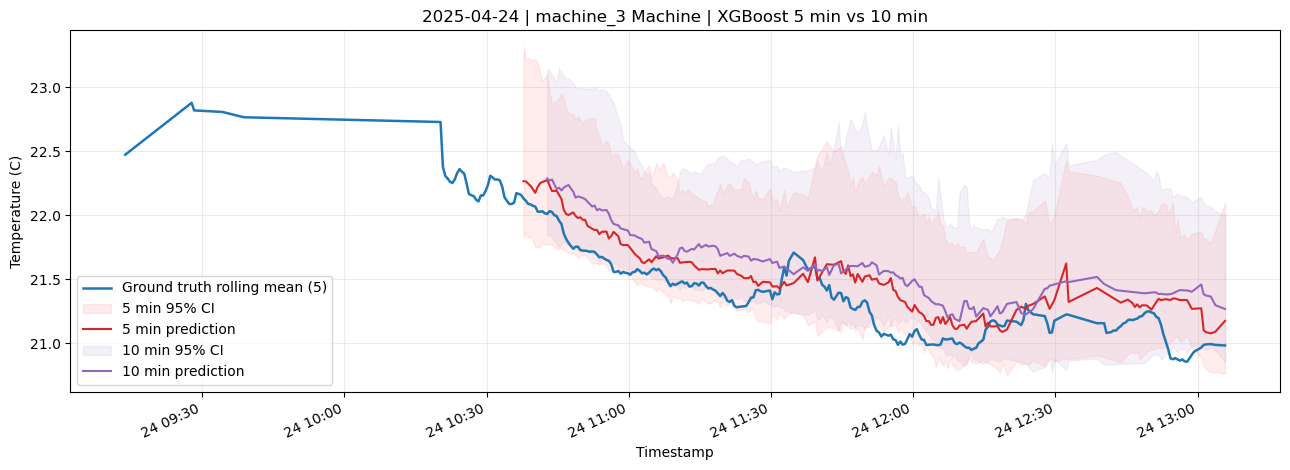

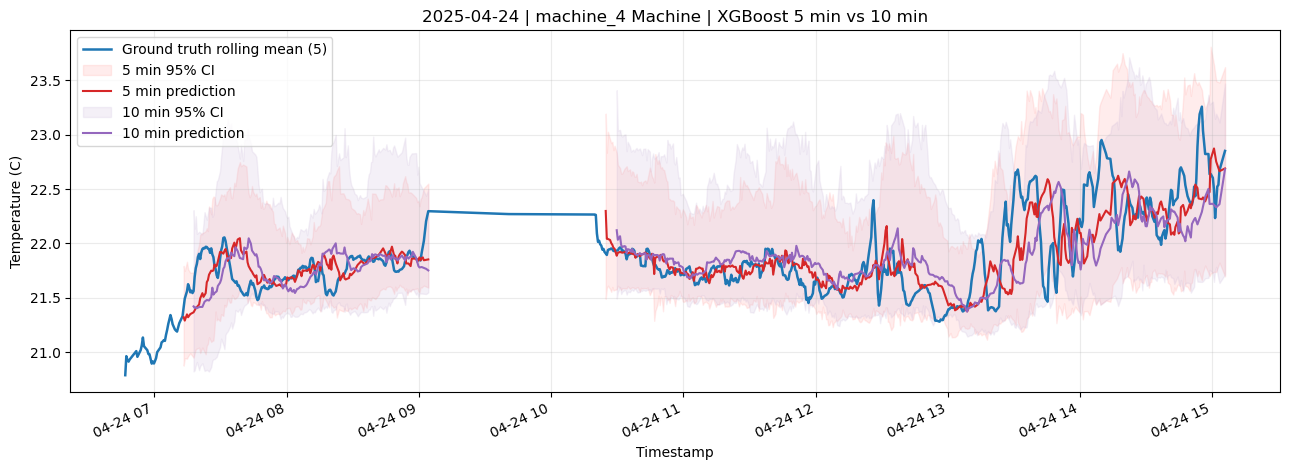

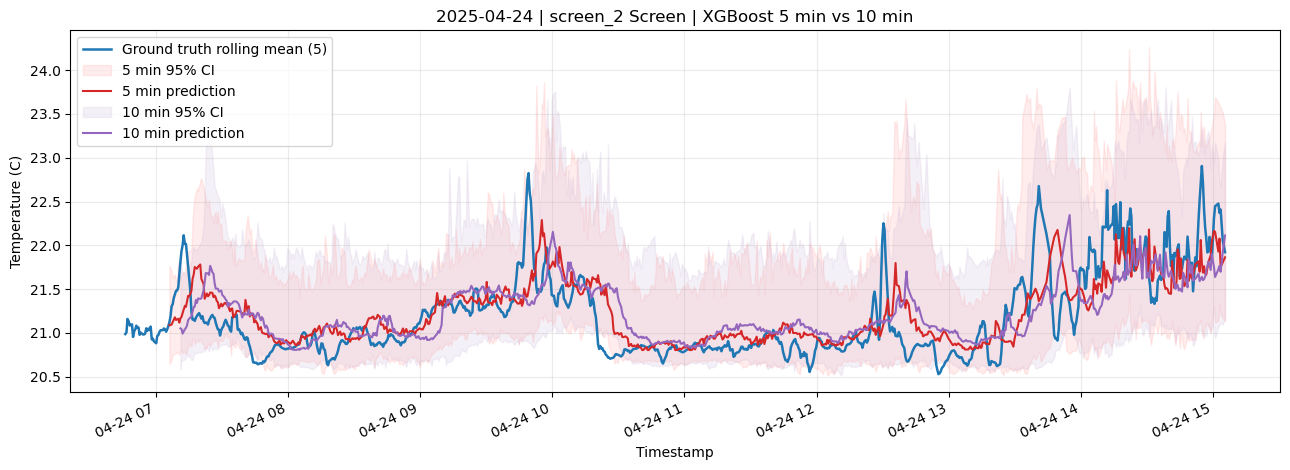

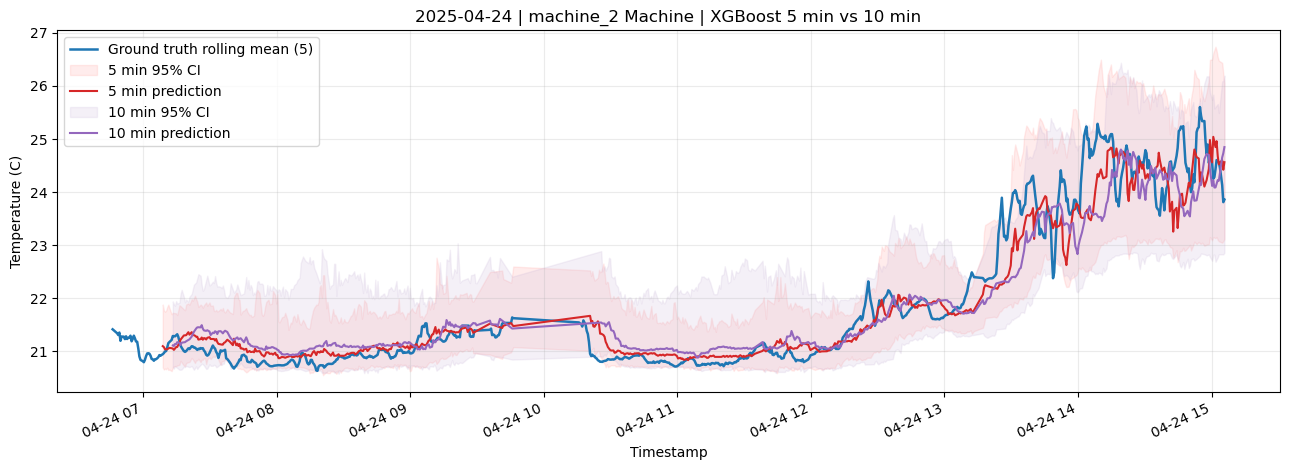

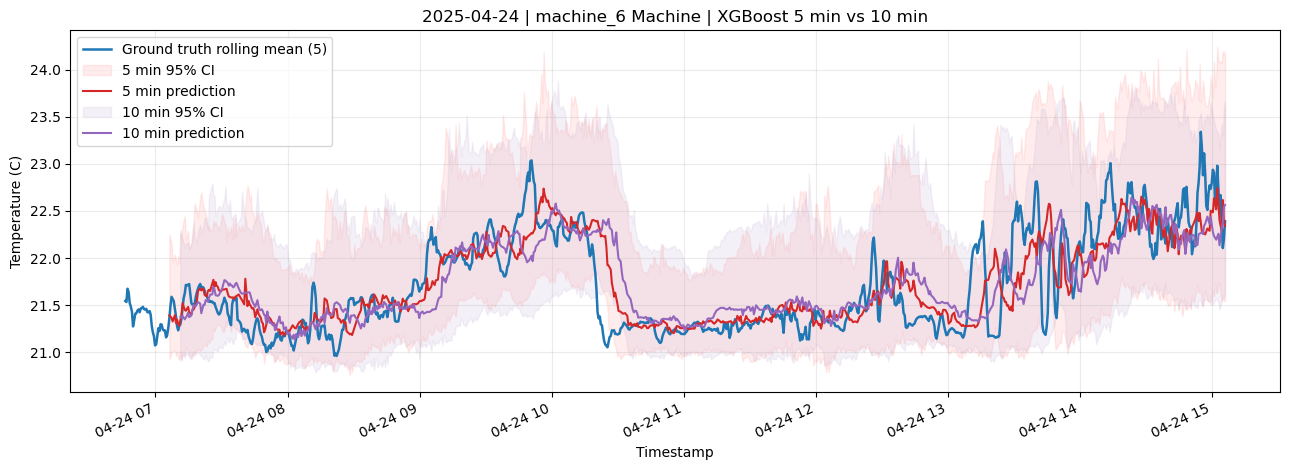

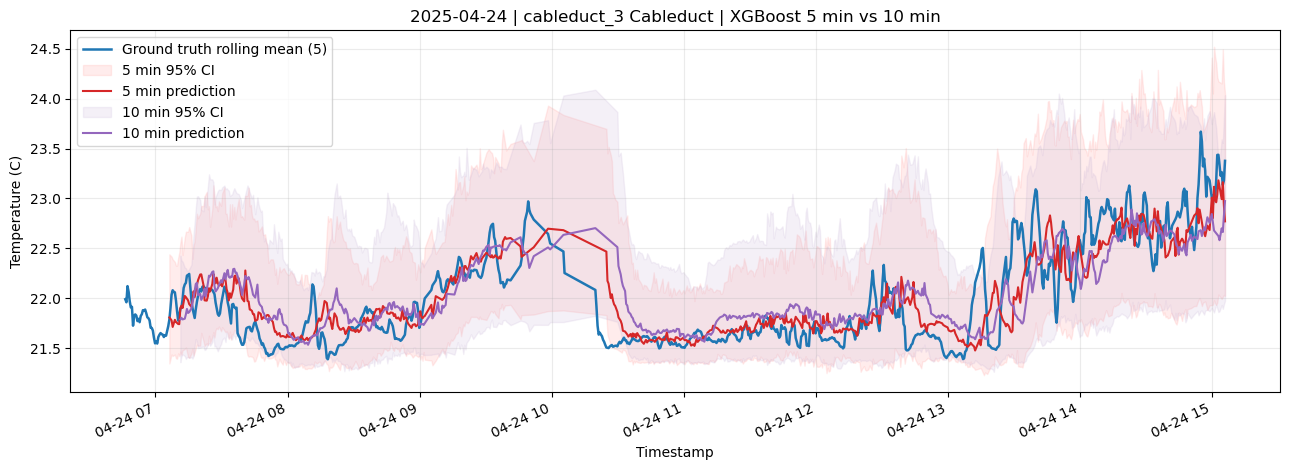

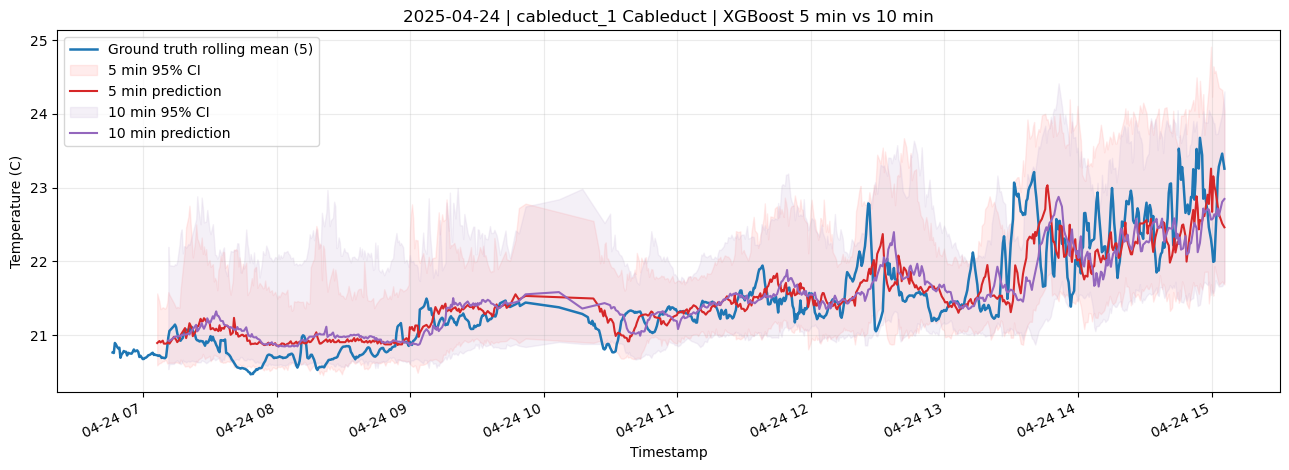

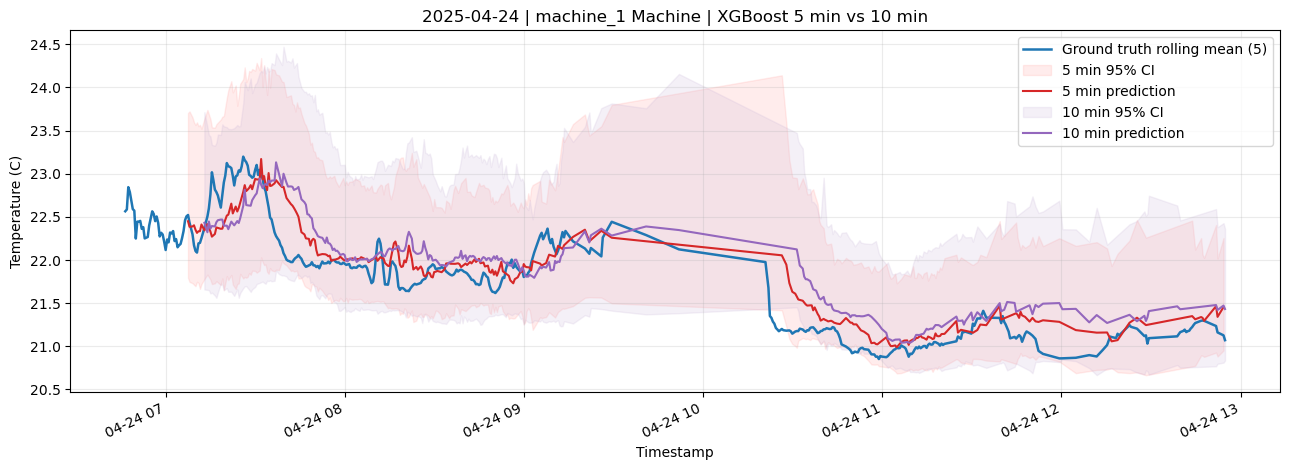

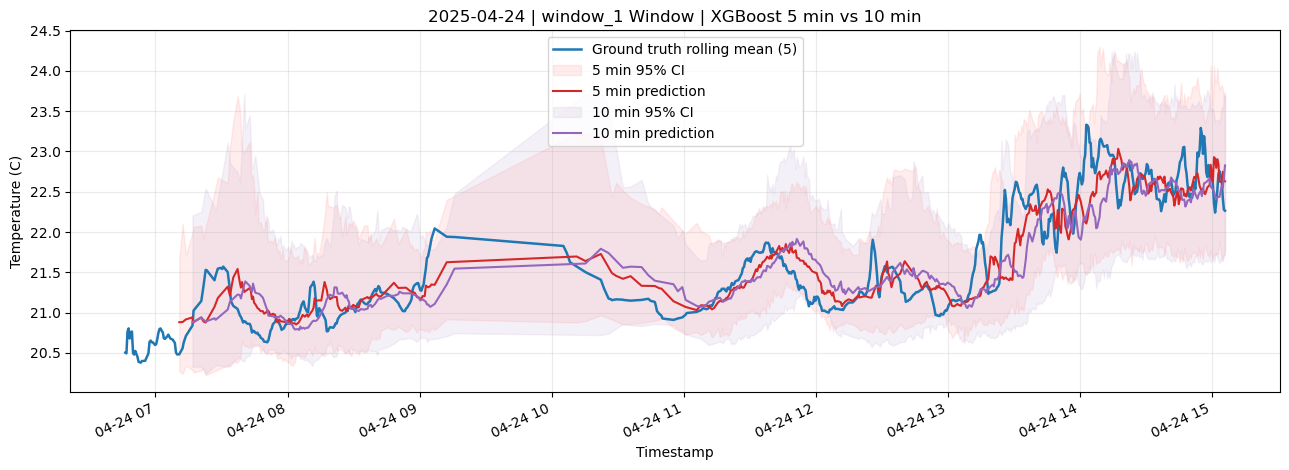

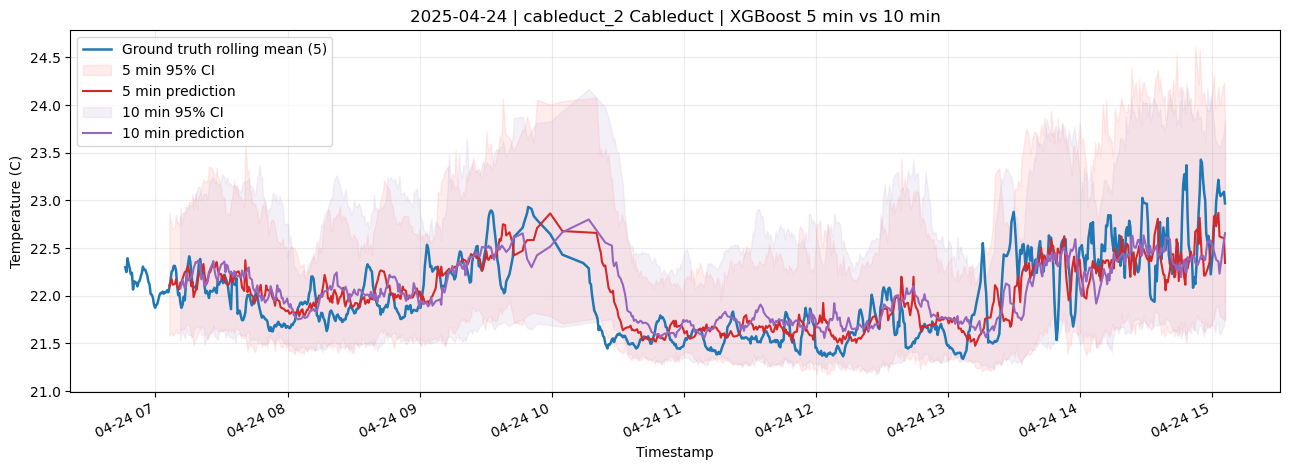

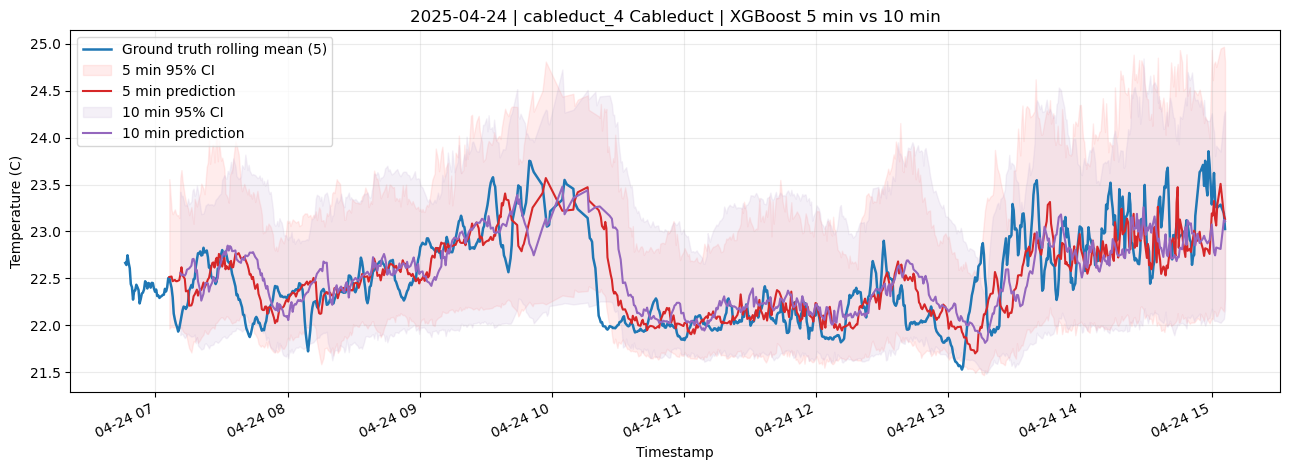

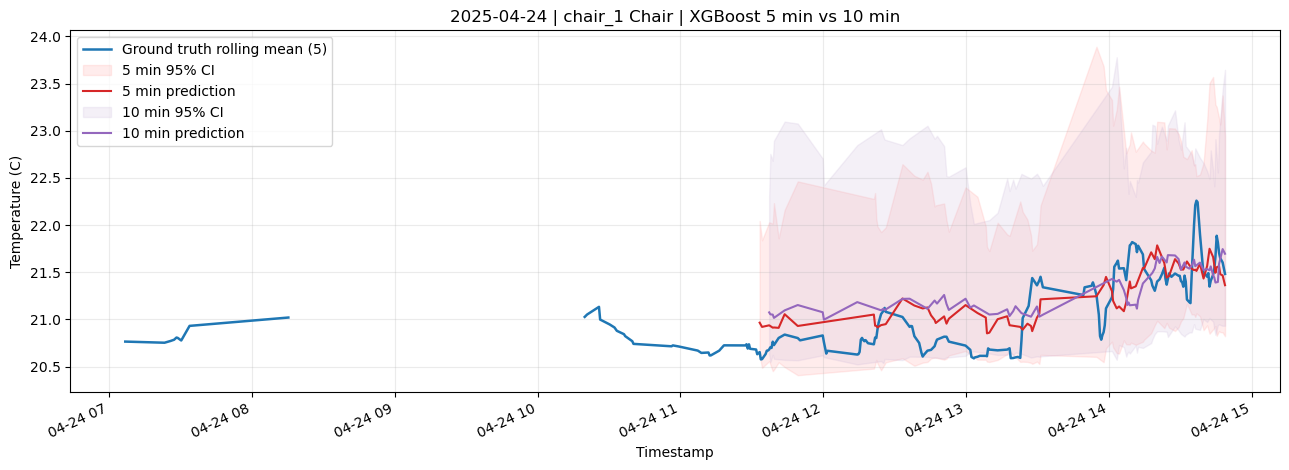

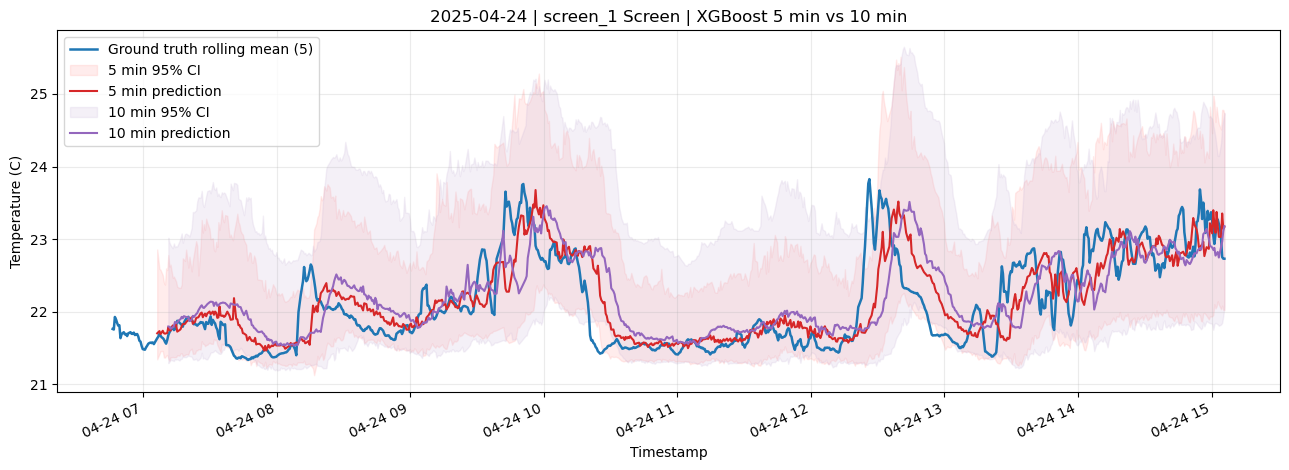

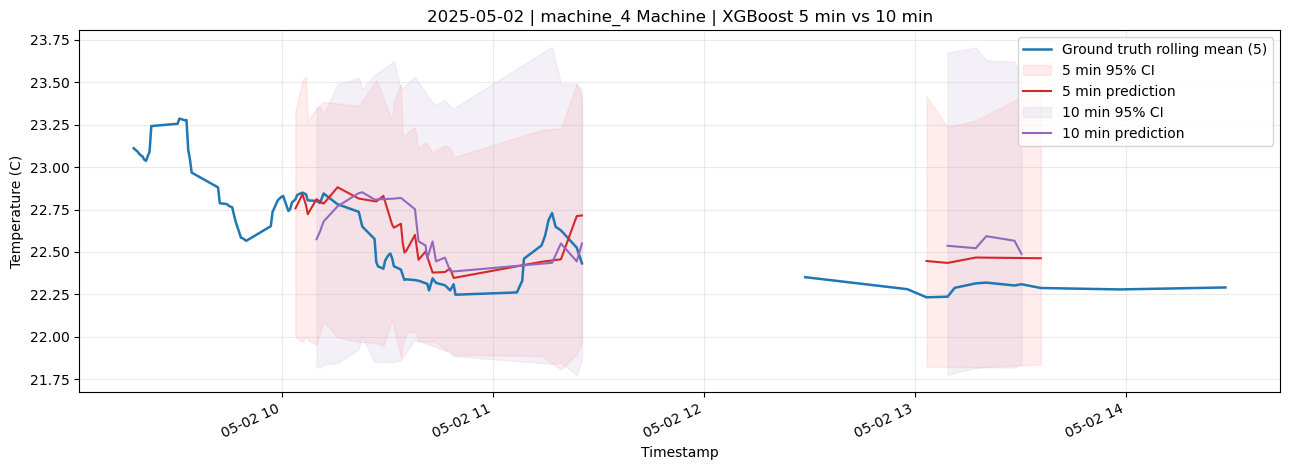

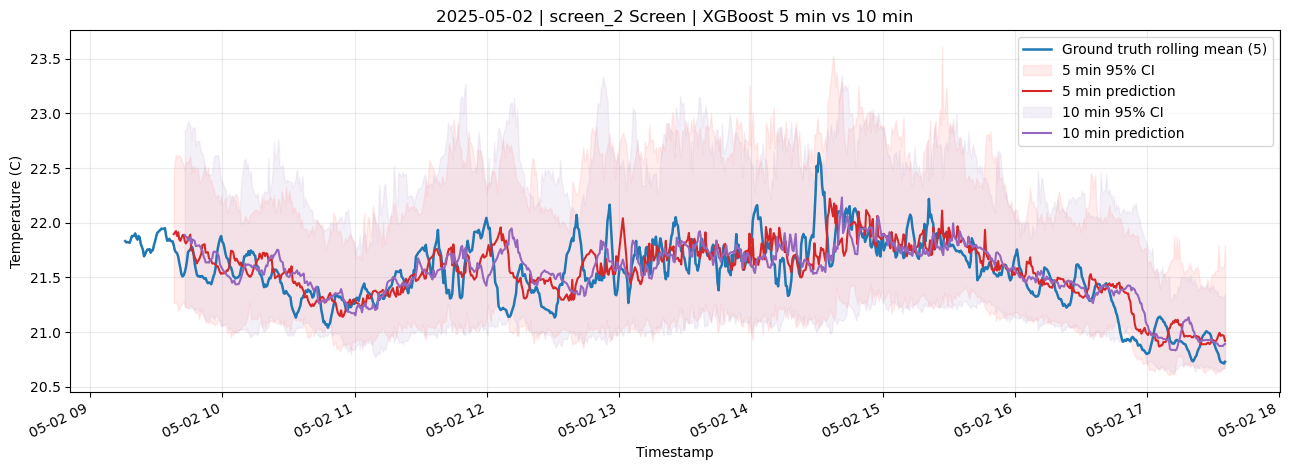

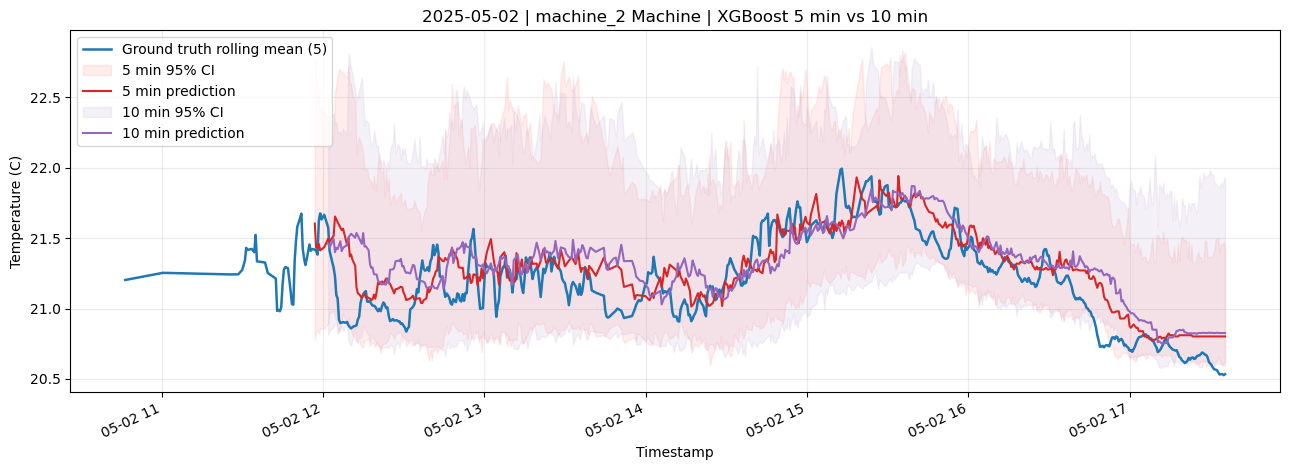

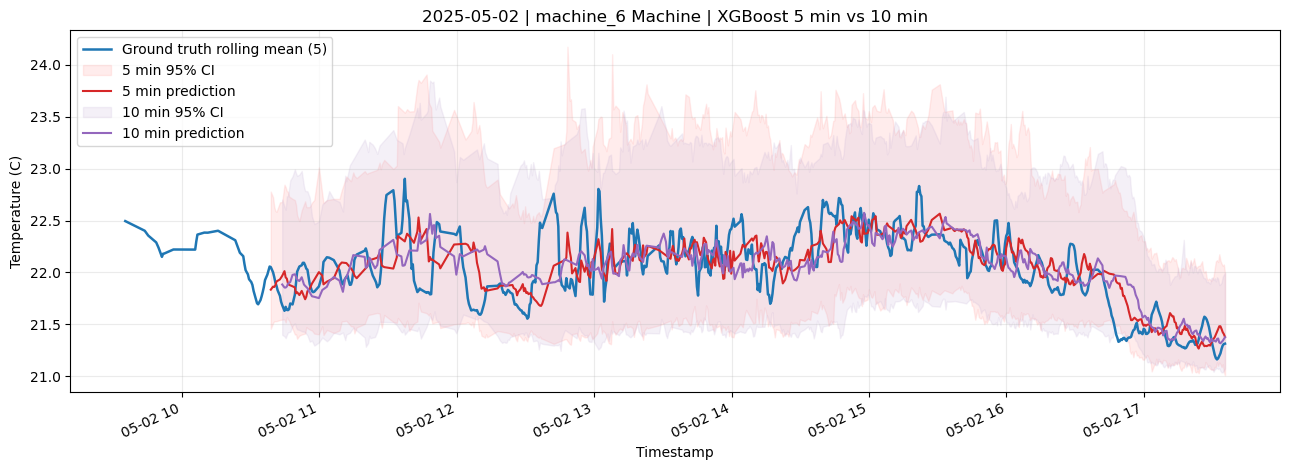

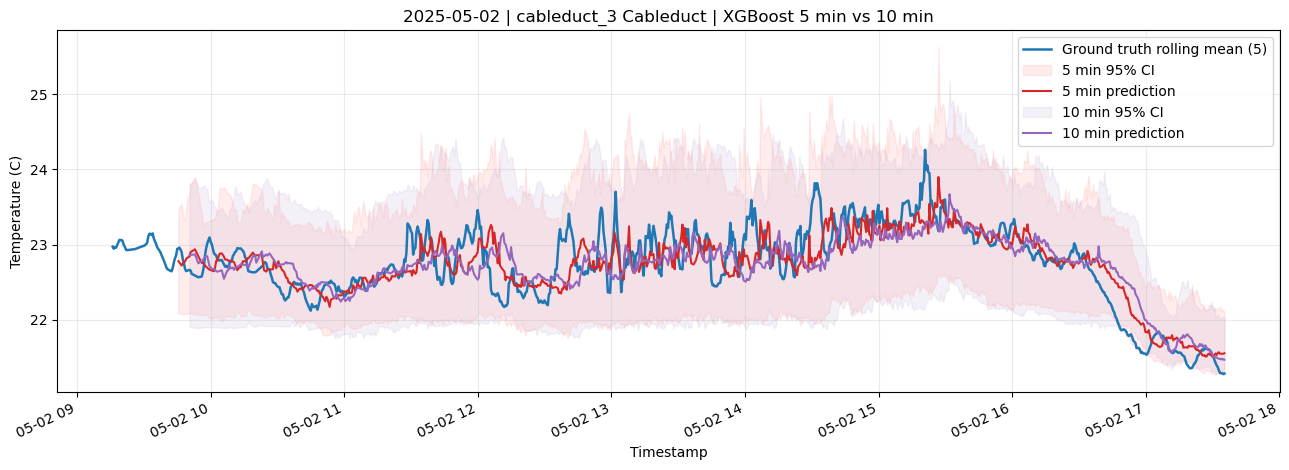

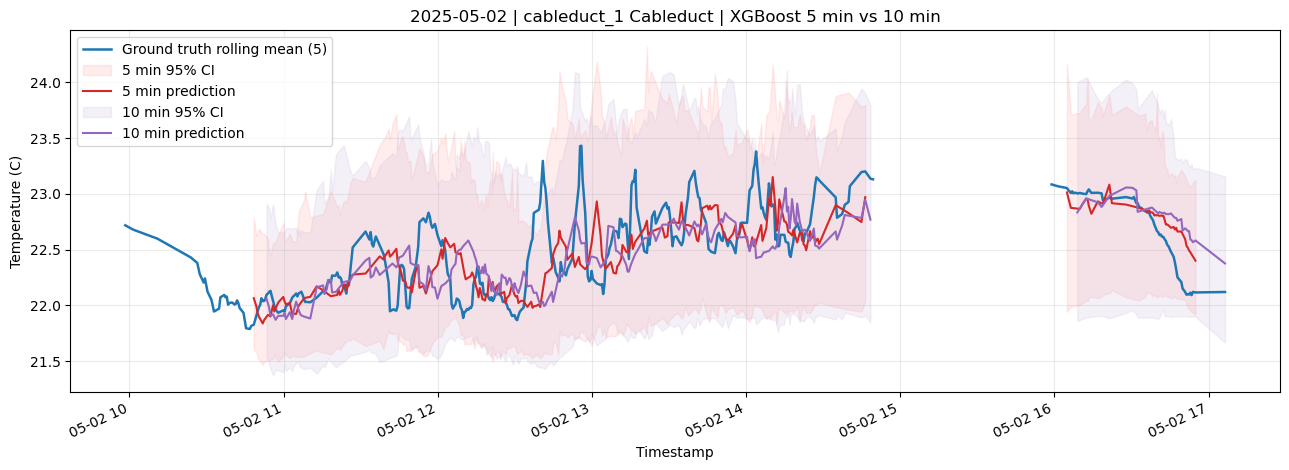

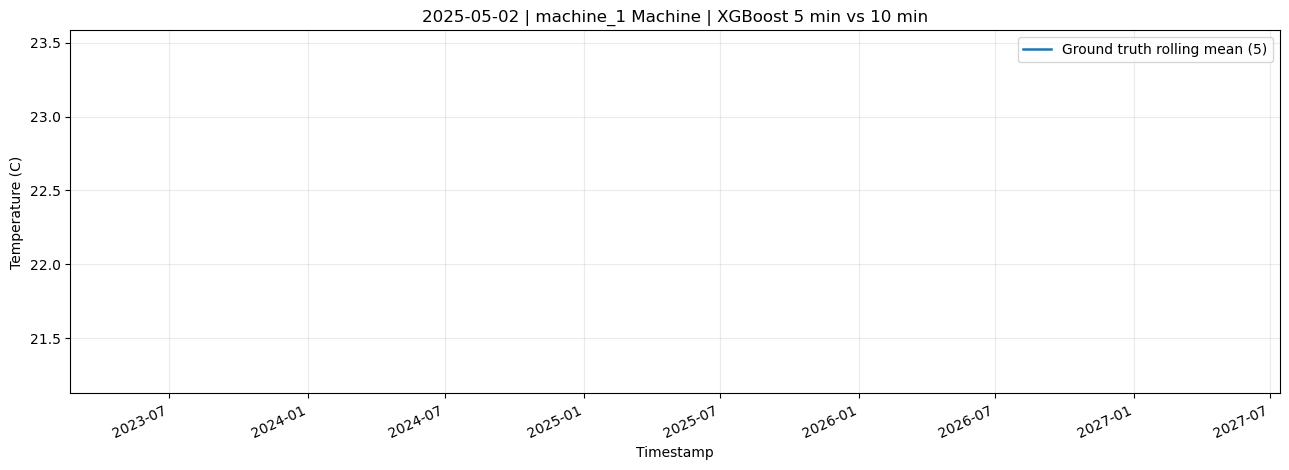

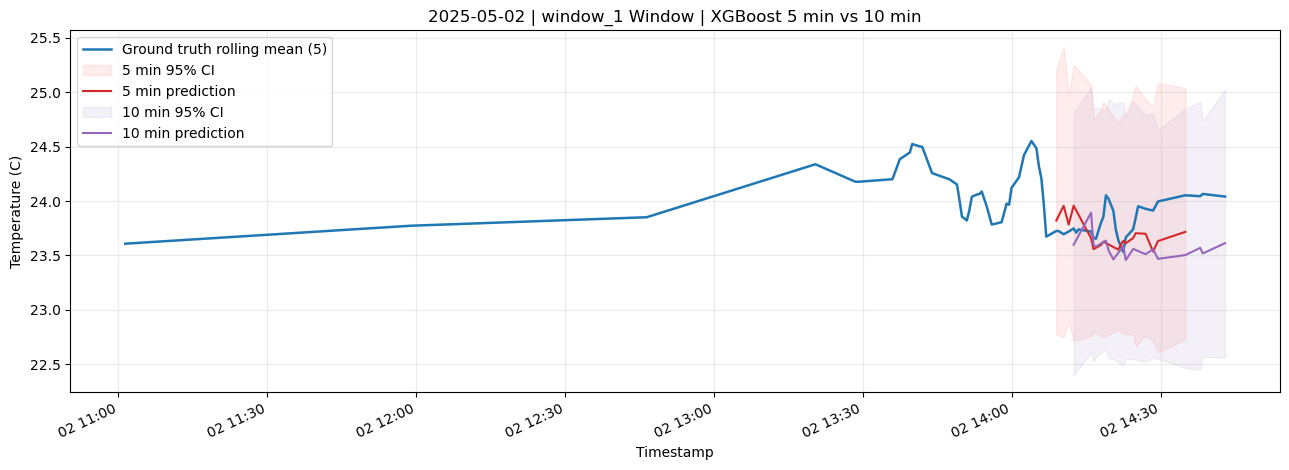

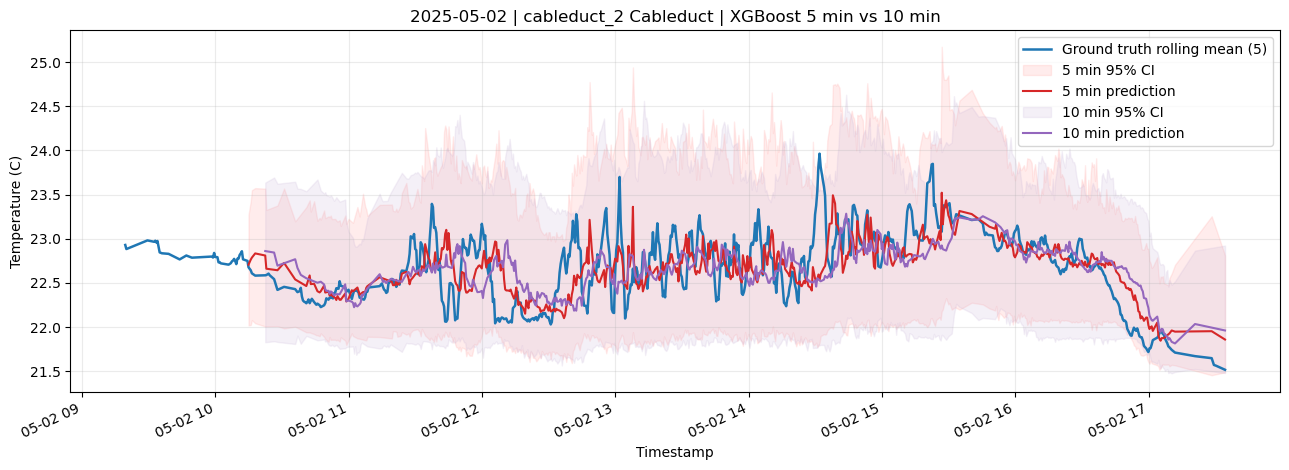

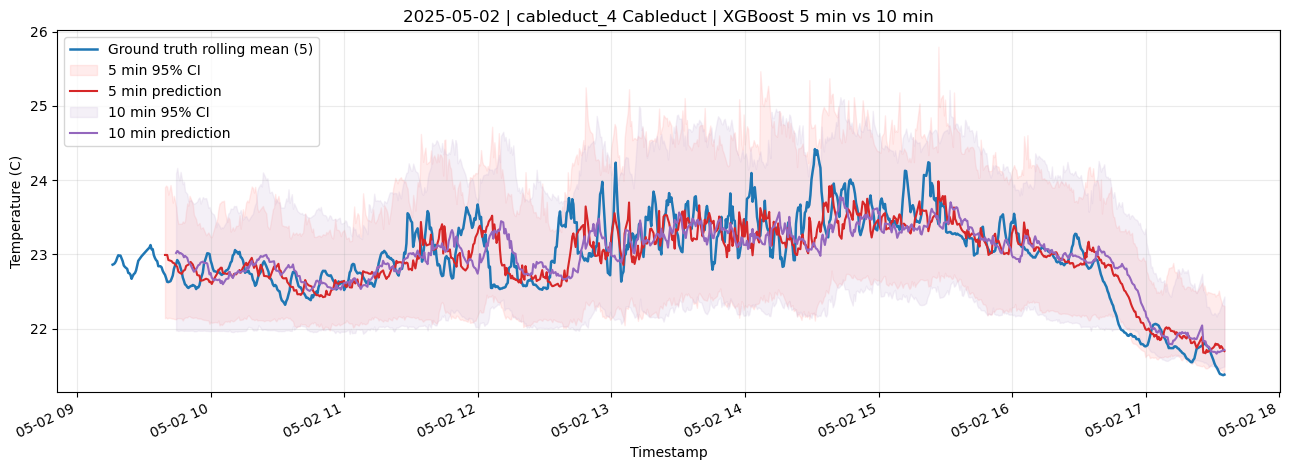

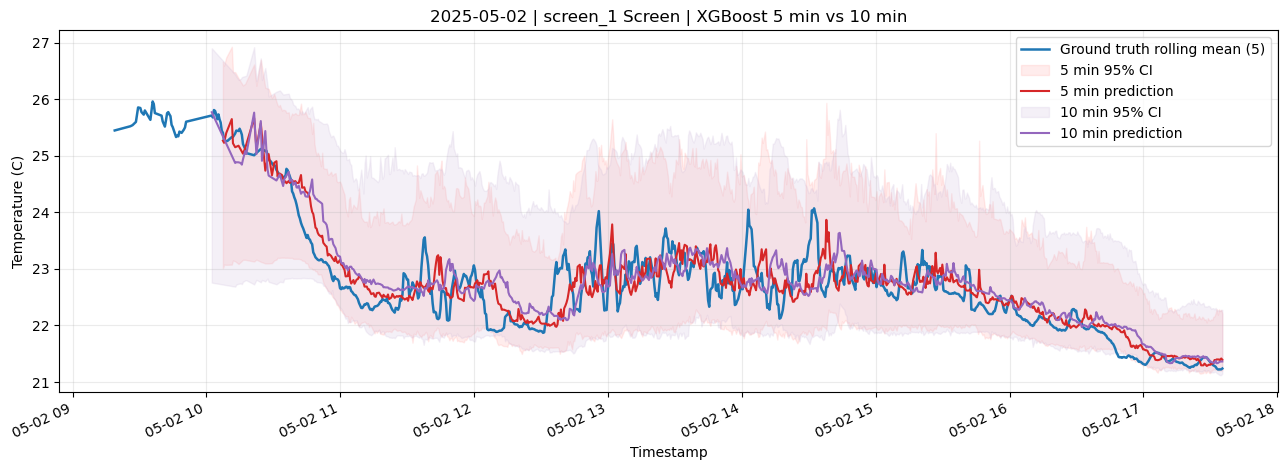

In [14]:
# Empty list = plot objects with the narrowest average CI width across both horizons.
PLOT_OBJECT_IDS = []
N_OBJECTS_TO_PLOT = 15  # Set None to plot all objects.
MAX_POINTS_PER_OBJECT = None  # Set an integer if a plot is too dense.
MAX_LINE_GAP_MINUTES = 60.0
GT_SMOOTH_WINDOW = 5  # Visual-only rolling mean window for ground truth.

def add_plot_segments(df, time_col, max_gap_minutes=60.0):
    df = df.sort_values(time_col).copy()
    gap = df[time_col].diff().dt.total_seconds().div(60)
    segment = gap.gt(max_gap_minutes).fillna(False).cumsum()
    return df.assign(_plot_segment=segment)

def smooth_ground_truth(df, value_col='ground_truth', window=5):
    df = df.sort_values('timestamp_dt').copy()
    if window is None or window <= 1 or df.empty:
        df['ground_truth_plot'] = df[value_col]
    else:
        df['ground_truth_plot'] = (
            df[value_col]
            .rolling(window=window, center=True, min_periods=1)
            .mean()
        )
    return df

def downsample_df(df, max_points):
    if max_points is None or len(df) <= max_points:
        return df
    keep_idx = np.linspace(0, len(df) - 1, max_points).astype(int)
    return df.iloc[keep_idx].copy()

timeline_gt = pd.read_csv(config.OBJECT_TIMELINE_CSV)
timeline_gt = timeline_gt[timeline_gt['people_or_machine'] == PEOPLE_OR_MACHINE].copy()
timeline_gt['timestamp_dt'] = pd.to_datetime(timeline_gt['timestamp'])
timeline_gt[TEMPERATURE_COLUMN] = pd.to_numeric(timeline_gt[TEMPERATURE_COLUMN], errors='coerce')
timeline_gt = timeline_gt.dropna(subset=['object_id', 'timestamp_dt', TEMPERATURE_COLUMN])
timeline_gt = (
    timeline_gt
    .groupby(['object_id', 'timestamp_dt'], as_index=False)
    .agg(
        canonical_label=('canonical_label', lambda s: s.mode().iloc[0] if not s.mode().empty else ''),
        ground_truth=(TEMPERATURE_COLUMN, 'mean'),
    )
)
timeline_gt['target_date'] = timeline_gt['timestamp_dt'].dt.date

plot_pred = test_pred.copy()
plot_pred['target_timestamp'] = pd.to_datetime(plot_pred['target_timestamp'])
plot_pred = (
    plot_pred
    .groupby(['object_id', 'canonical_label', 'target_minutes', 'target_timestamp'], as_index=False)
    .agg(
        prediction=('prediction', 'median'),
        ci_lower=('ci_lower', 'median'),
        ci_upper=('ci_upper', 'median'),
        prediction_rows=('prediction', 'size'),
    )
)
plot_pred['target_date'] = plot_pred['target_timestamp'].dt.date

print(f'GT plot rows from timeline: {len(timeline_gt):,}')
print(f'Prediction plot rows: {len(test_pred):,} -> {len(plot_pred):,} after target-time aggregation')

if PLOT_OBJECT_IDS:
    object_ids_to_plot = PLOT_OBJECT_IDS
else:
    object_ids_to_plot = confidence_pivot.mean(axis=1).sort_values().index.tolist()
    if N_OBJECTS_TO_PLOT is not None:
        object_ids_to_plot = object_ids_to_plot[:N_OBJECTS_TO_PLOT]

horizon_colors = {5.0: '#d62728', 10.0: '#9467bd'}
horizon_fill = {5.0: '#ff9896', 10.0: '#c5b0d5'}

for target_date in sorted(plot_pred['target_date'].unique()):
    print(f'Target date: {target_date}')
    for object_id in object_ids_to_plot:
        object_pred_day = plot_pred[(plot_pred['object_id'] == object_id) & (plot_pred['target_date'] == target_date)].copy()
        object_gt_day = timeline_gt[(timeline_gt['object_id'] == object_id) & (timeline_gt['target_date'] == target_date)].copy()
        object_gt_day = smooth_ground_truth(object_gt_day, window=GT_SMOOTH_WINDOW)
        if object_pred_day.empty and object_gt_day.empty:
            continue

        labels = []
        if not object_pred_day.empty:
            labels.extend(object_pred_day['canonical_label'].dropna().astype(str).tolist())
        if not object_gt_day.empty:
            labels.extend(object_gt_day['canonical_label'].dropna().astype(str).tolist())
        label = pd.Series(labels).mode().iloc[0] if labels else ''

        fig, ax = plt.subplots(figsize=(13, 4.8))

        gt_df = downsample_df(
            add_plot_segments(object_gt_day, 'timestamp_dt', MAX_LINE_GAP_MINUTES),
            MAX_POINTS_PER_OBJECT,
        )
        for segment_id, segment in gt_df.groupby('_plot_segment'):
            ax.plot(
                segment['timestamp_dt'],
                segment['ground_truth_plot'],
                color='#1f77b4',
                linewidth=1.8,
                label=f'Ground truth rolling mean ({GT_SMOOTH_WINDOW})' if segment_id == gt_df['_plot_segment'].min() else None,
            )

        for target_minutes in TARGET_MINUTES_LIST:
            part = object_pred_day[object_pred_day['target_minutes'] == target_minutes].copy()
            if part.empty:
                continue
            part = downsample_df(
                add_plot_segments(part, 'target_timestamp', MAX_LINE_GAP_MINUTES),
                MAX_POINTS_PER_OBJECT,
            )
            first_segment = part['_plot_segment'].min()
            for segment_id, segment in part.groupby('_plot_segment'):
                ax.fill_between(
                    segment['target_timestamp'],
                    segment['ci_lower'],
                    segment['ci_upper'],
                    color=horizon_fill.get(target_minutes, 'orange'),
                    alpha=0.18,
                    label=f'{target_minutes:g} min 95% CI' if segment_id == first_segment else None,
                )
                ax.plot(
                    segment['target_timestamp'],
                    segment['prediction'],
                    color=horizon_colors.get(target_minutes, '#333333'),
                    linewidth=1.5,
                    label=f'{target_minutes:g} min prediction' if segment_id == first_segment else None,
                )

        ax.set_title(f'{target_date} | {object_id} {label} | XGBoost 5 min vs 10 min')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Temperature (C)')
        ax.grid(alpha=0.25)
        ax.legend(loc='best')
        fig.autofmt_xdate(rotation=25)
        fig.tight_layout()


## Overall Error Distribution by Horizon


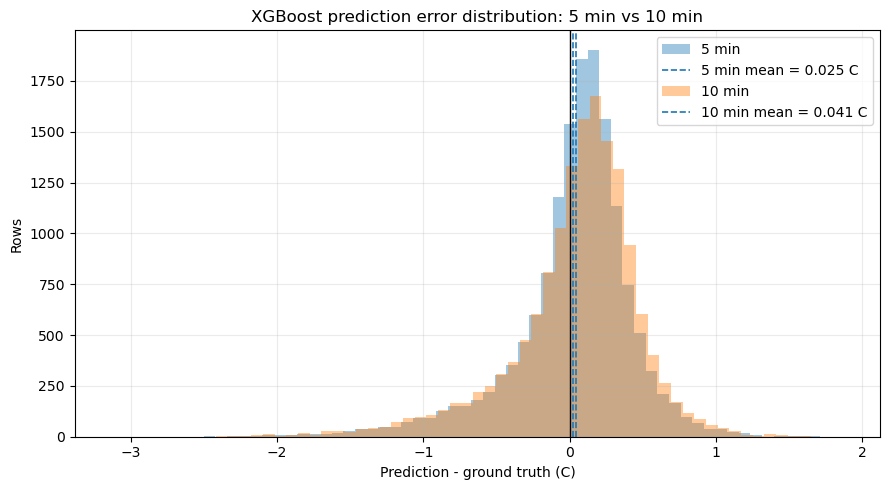

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
for target_minutes in TARGET_MINUTES_LIST:
    part = test_pred[test_pred['target_minutes'] == target_minutes]
    ax.hist(part['error'], bins=60, alpha=0.42, label=f'{target_minutes:g} min')
    ax.axvline(
        part['error'].mean(),
        linestyle='--',
        linewidth=1.2,
        label=f'{target_minutes:g} min mean = {part["error"].mean():.3f} C',
    )
ax.axvline(0, color='black', linewidth=1)
ax.set_title('XGBoost prediction error distribution: 5 min vs 10 min')
ax.set_xlabel('Prediction - ground truth (C)')
ax.set_ylabel('Rows')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()


## Error Distribution by Category


,canonical_label,target_minutes,rows,mean_error,median_error,mae,rmse,p05,p95
0,Cableduct,5.0,6411,0.004902,0.077327,0.317044,0.443145,-0.852417,0.579829
1,Cableduct,10.0,6394,0.013348,0.095641,0.339314,0.460272,-0.866668,0.615080
2,Chair,5.0,132,0.097371,0.184327,0.322080,0.429491,-0.566397,0.547404
3,Chair,10.0,133,0.178581,0.279657,0.362144,0.436342,-0.564765,0.612387
4,Machine,5.0,4487,0.036279,0.084190,0.256811,0.365384,-0.655258,0.507348
5,Machine,10.0,4458,0.063447,0.121136,0.296852,0.405461,-0.702351,0.557665
6,Screen,5.0,3676,0.050717,0.111240,0.311320,0.445282,-0.818616,0.639764
7,Screen,10.0,3642,0.076806,0.136714,0.352746,0.490221,-0.864025,0.735052
8,Window,5.0,644,-0.022321,0.013208,0.292829,0.389561,-0.685143,0.511402
9,Window,10.0,648,-0.065655,-0.008970,0.350557,0.446080,-0.855608,0.549285


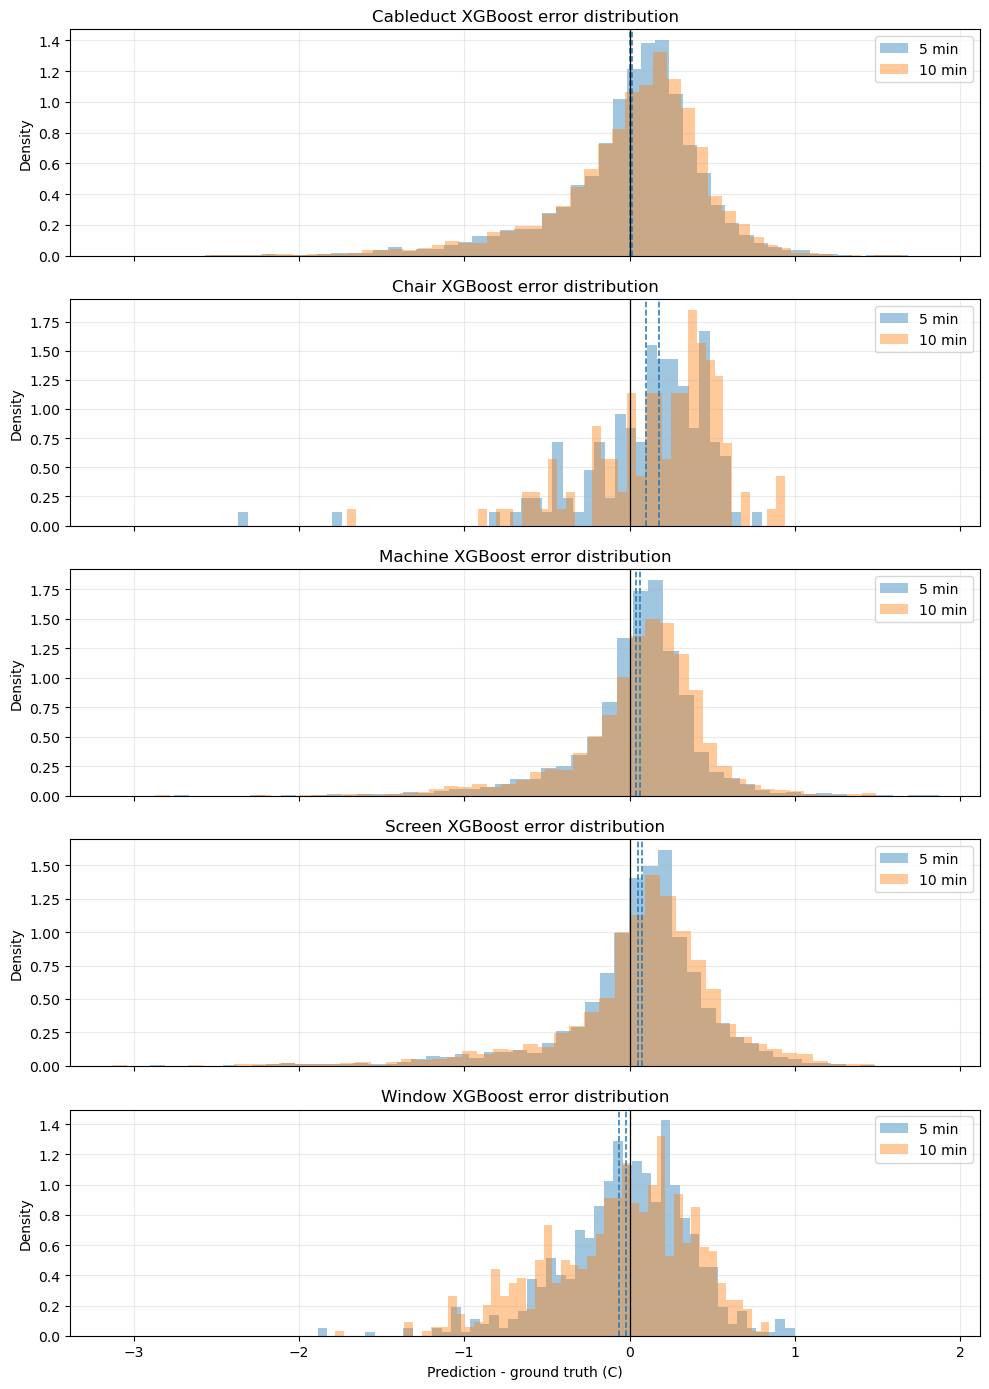

In [16]:
def error_summary_table(df, group_cols):
    rows = []
    for keys, part in df.groupby(group_cols, sort=True, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        error = part['error'].dropna()
        if error.empty:
            continue
        row = dict(zip(group_cols, keys))
        row.update({
            'rows': len(error),
            'mean_error': error.mean(),
            'median_error': error.median(),
            'mae': error.abs().mean(),
            'rmse': np.sqrt((error ** 2).mean()),
            'p05': error.quantile(0.05),
            'p95': error.quantile(0.95),
        })
        rows.append(row)
    return pd.DataFrame(rows)

category_error_summary = error_summary_table(test_pred, ['canonical_label', 'target_minutes'])
display(category_error_summary.sort_values(['canonical_label', 'target_minutes']))

category_labels = sorted(test_pred['canonical_label'].dropna().unique())
fig, axes = plt.subplots(
    len(category_labels),
    1,
    figsize=(10, max(3.2, 2.8 * len(category_labels))),
    sharex=True,
)
if len(category_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, category_labels):
    for target_minutes in TARGET_MINUTES_LIST:
        part = test_pred[
            (test_pred['canonical_label'] == label) &
            (test_pred['target_minutes'] == target_minutes)
        ]['error'].dropna()
        if part.empty:
            continue
        ax.hist(part, bins=50, alpha=0.42, density=True, label=f'{target_minutes:g} min')
        ax.axvline(part.mean(), linestyle='--', linewidth=1.1)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_title(f'{label} XGBoost error distribution')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

axes[-1].set_xlabel('Prediction - ground truth (C)')
fig.tight_layout()


## Error Distribution by Object


,object_id,canonical_label,target_minutes,rows,mean_error,median_error,mae,rmse,p05,p95
0,cableduct_1,Cableduct,5.0,1236,0.015061,0.094149,0.339823,0.473941,-0.925232,0.598466
1,cableduct_1,Cableduct,10.0,1235,0.008287,0.108421,0.360745,0.489643,-1.034647,0.638126
2,cableduct_2,Cableduct,5.0,1582,0.009901,0.088191,0.327725,0.456430,-0.903102,0.611754
3,cableduct_2,Cableduct,10.0,1589,0.019872,0.113155,0.348525,0.472365,-0.949255,0.626082
4,cableduct_3,Cableduct,5.0,1762,0.008971,0.071042,0.283102,0.392585,-0.774322,0.533184
5,cableduct_3,Cableduct,10.0,1754,0.014337,0.090571,0.314993,0.417366,-0.793629,0.564597
6,cableduct_4,Cableduct,5.0,1831,-0.010191,0.063961,0.325101,0.455684,-0.848606,0.579512
7,cableduct_4,Cableduct,10.0,1816,0.010125,0.078140,0.340169,0.468380,-0.837668,0.638054
8,chair_1,Chair,5.0,132,0.097371,0.184327,0.322080,0.429491,-0.566397,0.547404
9,chair_1,Chair,10.0,133,0.178581,0.279657,0.362144,0.436342,-0.564765,0.612387


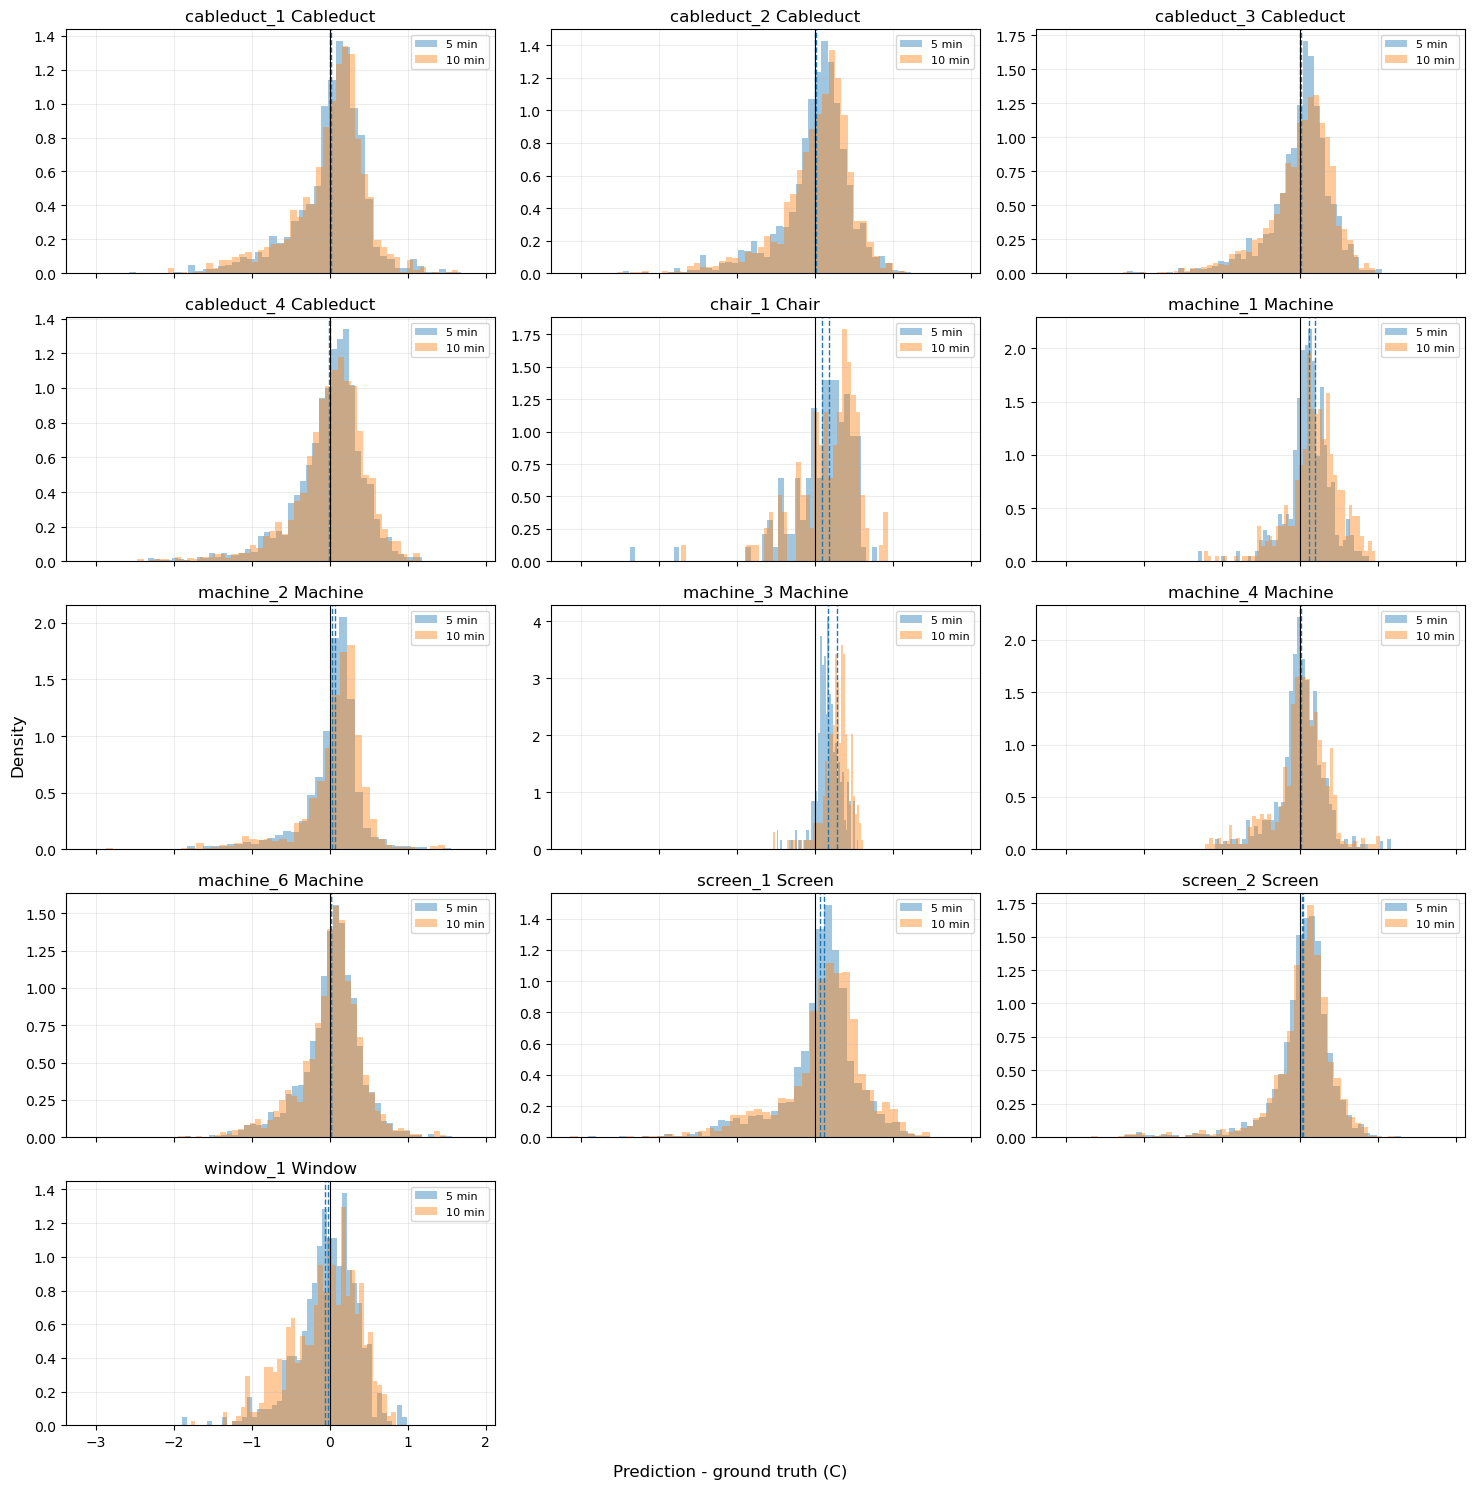

In [17]:
OBJECT_ERROR_IDS = []  # Empty list = all objects in test_pred.
OBJECT_ERROR_MAX_OBJECTS = None  # Set an integer if the grid is too large.
OBJECT_ERROR_BINS = 45

object_error_summary = error_summary_table(test_pred, ['object_id', 'canonical_label', 'target_minutes'])
display(object_error_summary.sort_values(['canonical_label', 'object_id', 'target_minutes']))

if OBJECT_ERROR_IDS:
    object_ids_for_error = OBJECT_ERROR_IDS
else:
    object_order = (
        test_pred[['object_id', 'canonical_label']]
        .drop_duplicates()
        .sort_values(['canonical_label', 'object_id'])
    )
    object_ids_for_error = object_order['object_id'].tolist()
    if OBJECT_ERROR_MAX_OBJECTS is not None:
        object_ids_for_error = object_ids_for_error[:OBJECT_ERROR_MAX_OBJECTS]

n_objects = len(object_ids_for_error)
ncols = 3
nrows = int(np.ceil(n_objects / ncols)) if n_objects else 1
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, max(3.2, 3.0 * nrows)),
    sharex=True,
    sharey=False,
)
axes = np.atleast_1d(axes).ravel()

for ax, object_id in zip(axes, object_ids_for_error):
    object_rows = test_pred[test_pred['object_id'] == object_id]
    label = object_rows['canonical_label'].mode().iloc[0] if not object_rows['canonical_label'].mode().empty else ''
    for target_minutes in TARGET_MINUTES_LIST:
        part = object_rows[object_rows['target_minutes'] == target_minutes]['error'].dropna()
        if part.empty:
            continue
        ax.hist(part, bins=OBJECT_ERROR_BINS, alpha=0.42, density=True, label=f'{target_minutes:g} min')
        ax.axvline(part.mean(), linestyle='--', linewidth=1.0)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{object_id} {label}')
    ax.grid(alpha=0.22)
    ax.legend(loc='best', fontsize=8)

for ax in axes[n_objects:]:
    ax.axis('off')

fig.supxlabel('Prediction - ground truth (C)')
fig.supylabel('Density')
fig.tight_layout()


## Test Predictions Preview


In [18]:
preview_columns = [
    'target_minutes',
    'object_id',
    'timestamp',
    'target_timestamp',
    'canonical_label',
    'source_temp',
    'target_temp',
    'prediction',
    'ci_lower',
    'ci_upper',
    'error',
    'covered_by_95ci',
]
test_pred[preview_columns].head(20)


,target_minutes,object_id,timestamp,target_timestamp,canonical_label,source_temp,target_temp,prediction,ci_lower,ci_upper,error,covered_by_95ci
0,5.0,cableduct_1,2025-04-24 07:01:17,2025-04-24 07:06:18,Cableduct,20.722349,20.768026,20.893024,20.590988,21.565582,0.124998,True
1,5.0,cableduct_1,2025-04-24 07:01:48,2025-04-24 07:07:18,Cableduct,20.758368,20.736496,20.947248,20.612541,21.450960,0.210752,True
2,5.0,cableduct_1,2025-04-24 07:02:18,2025-04-24 07:07:18,Cableduct,20.678381,20.736496,20.893272,20.627024,21.452465,0.156776,True
3,5.0,cableduct_1,2025-04-24 07:02:48,2025-04-24 07:07:48,Cableduct,20.700623,20.703457,20.900742,20.622541,21.351851,0.197285,True
4,5.0,cableduct_1,2025-04-24 07:03:18,2025-04-24 07:08:48,Cableduct,20.774504,20.703279,20.965059,20.639303,21.408087,0.261780,True
5,5.0,cableduct_1,2025-04-24 07:03:48,2025-04-24 07:08:48,Cableduct,20.743622,20.703279,20.884563,20.654423,21.349039,0.181284,True
6,5.0,cableduct_1,2025-04-24 07:04:17,2025-04-24 07:09:18,Cableduct,20.796827,20.656719,20.884563,20.645521,21.368332,0.227844,True
7,5.0,cableduct_1,2025-04-24 07:04:48,2025-04-24 07:09:48,Cableduct,20.749052,20.758543,20.884563,20.663198,21.357227,0.126020,True
8,5.0,cableduct_1,2025-04-24 07:05:17,2025-04-24 07:10:18,Cableduct,20.743179,20.672283,20.884563,20.657679,21.381968,0.212280,True
9,5.0,cableduct_1,2025-04-24 07:05:48,2025-04-24 07:10:48,Cableduct,20.623709,20.647320,20.892033,20.615307,21.439148,0.244713,True
